# 资产定价检验：预测 Expected Shortfall 与未来股票收益

本 notebook 只使用前一步冻结的样本外预测，不使用资产定价结果选择模型或修改 ES 定义。

主要检验：

1. structure MDN模型的 5% return-ES 单变量组合排序；
2. High ES minus Low ES 的均值、Newey–West $t$ 值和因子调整 alpha；
3. Fama–MacBeth 横截面回归；
4. Structured K3 的 adverse contribution 与 severity 定价；
5. severity premium 是否随 macro-conditioned adverse weight 变化；
6. 1%/10% ES、五组、breakpoints 和 microcap 的稳健性。

时间约定始终为：$widehat{ES}_{i,t}\rightarrow R_{i,t+1}$。`mthcaldt` 是信号形成月，`target_ret_final` 是下一月收益。

**ES 口径**：$ES_\alpha=E[R\mid R\le VaR_\alpha]$，亏损保留负数。


In [1]:
# ==========================================
# 1. 设置路径、模型版本和主要参数
# ==========================================
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/pricing-matplotlib")

from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display


# warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# 该时间戳必须对应已经冻结的模型预测版本
timestamp = "20260924_0807" # rank + training 72 months + ffi12 + random seed 42 + new quantile levels
timestamp = "20260925_0018" # rank + training 72 months + ffi12 + random seed 42 + new quantile levels + flim

alphas = (0.05, 0.10)
industry_type = "ffi12"  # 'ffi12' 或 'ffi49'
PRIMARY_ALPHA = 0.1
PRIMARY_GROUPS = 10
NW_LAGS = 12

project_root = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")
forecast_dir = Path("/Users/jianbinchen/Downloads/results")
result_dir = project_root / "output"
figure_dir = project_root / "overleaf/fig"
result_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

WRDS_db_path = Path("/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite")

model_order = [
    "rolling_normal", 
    "linear_quantile", 
    "fused_normal_k1", 
    "fused_normal_k3", 
    "structured_normal_k3", 
    # "film_sigma", 
    # "film_all"
    ]
model_labels = {
    "rolling_normal": "Rolling Normal", 
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1", 
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
    # "film_sigma": "FiLM Sigma",
    # "film_all": "FiLM All"
}
model_files = {
    "rolling_normal": forecast_dir / f"rolling_normal_forecasts_{timestamp}.parquet",
    "linear_quantile": forecast_dir / f"linear_quantile_forecasts_{timestamp}.parquet",
    "fused_normal_k1": forecast_dir / f"fused_k1_forecasts_{timestamp}.parquet",
    "fused_normal_k3": forecast_dir / f"fused_k3_forecasts_{timestamp}.parquet",
    "structured_normal_k3": forecast_dir / f"structured_forecasts_{timestamp}.parquet",
    # "film_sigma": forecast_dir / f"film_sigma_forecasts_{timestamp}.parquet",
    # "film_all": forecast_dir / f"film_all_forecasts_{timestamp}.parquet",
}

model_colors = {
    "rolling_normal": "#4C78A8", 
    "linear_quantile": "#F2A541", 
    "fused_normal_k1": "#8C8C8C",
    "fused_normal_k3": "#B279A2", 
    "structured_normal_k3": "#2F6B4F",
    "film_sigma": "#D98C3F",
    "film_all": "#E15759",
}
signal_colors = {
    "Total ES (5%)": "#2F6B4F", 
    "Adverse contribution": "#D98C3F", 
    "Adverse severity": "#4C78A8",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 2. 构建资产定价样本

- `mthcap` 使用信号月末市值，因此 value weights 不使用未来信息；
- `crsp_msenames` 按信号日期识别 common shares 和 NYSE 股票；
- NYSE 股票只用于形成 breakpoints，全部合格股票随后参与组合；
- FF factors 与下一月组合收益对齐。

In [2]:
# ==========================================
# 2.1 读取 Structured components、公司特征和 WRDS 数据
# ==========================================
structured_components = pd.read_parquet(result_dir / f"structured_components_{timestamp}.parquet")
structured_components["mthcaldt"] = pd.to_datetime(structured_components["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([structured_components.head(), structured_components.tail()]))

micro_data = pd.read_parquet(project_root / "data/micro_data.parquet")
micro_data["mthcaldt"] = pd.to_datetime(micro_data["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([micro_data.head(), micro_data.tail()]))

with sqlite3.connect(WRDS_db_path) as conn:
    crsp_names = pd.read_sql_query(
        "SELECT permno, namedt, nameendt, shrcd, exchcd FROM crsp_msenames", conn
    )
    ff3 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, umd, rf FROM ff_factors_monthly", conn
    )
    ff5 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, rmw, cma, umd, rf FROM ff_fivefactors_monthly", conn
    )

structured_components["permno"] = structured_components["permno"].astype("Int64")
micro_data["permno"] = micro_data["permno"].astype("Int64")

ff3["return_date"] = pd.to_datetime(dict(year=ff3["year"].astype(int), month=ff3["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff5["return_date"] = pd.to_datetime(dict(year=ff5["year"].astype(int), month=ff5["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff3 = ff3.rename(columns={c: f"{c}_ff3" for c in ["mktrf", "smb", "hml", "umd", "rf"]})
ff5 = ff5.rename(columns={c: f"{c}_ff5" for c in ["mktrf", "smb", "hml", "rmw", "cma", "umd", "rf"]})
factor_data = ff3.drop(columns=["year", "month"]).merge(
    ff5.drop(columns=["year", "month"]), on="return_date", validate="one_to_one"
)
display(pd.concat([factor_data.head(), factor_data.tail()]))

,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable
0,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.126501,-0.169206,2.378455,0.528514,False,-0.169206,0.528514,0.002418,0.082986,0.635823,-0.162251,-0.103163,0.358145,-0.008407,0.059959,0.175081,-0.149088,-0.026102,0.113341,0.129864,0.185444,0.189096,-0.211221,-0.039941,0.149524,1.003325
1,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.269773,-0.332184,2.378455,0.528514,True,-0.332184,0.528514,-0.083419,0.136923,0.917017,-0.332797,-0.305181,0.358145,0.025016,0.116528,0.040878,-0.307075,-0.012553,0.113341,0.150870,0.201832,0.042105,-0.343201,-0.014450,0.852912,0.763699
2,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.136563,-0.170743,2.378455,0.528514,True,-0.170743,0.528514,-0.034472,0.074874,0.912849,-0.170997,-0.156094,0.358145,0.001913,0.054184,0.037957,-0.153786,-0.005837,0.113341,0.095101,0.114697,0.049194,-0.179112,-0.008811,0.556754,1.038915
3,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.464835,-0.553728,2.378455,0.528514,True,-0.553728,0.528514,-0.214299,0.190412,0.994956,-0.553892,-0.551098,0.358145,0.028570,0.144049,0.002200,-0.501670,-0.001104,0.113341,0.307497,0.255553,0.002844,-0.536784,-0.001527,1.438543,1.344660
4,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.184691,-0.239590,2.378455,0.528514,True,-0.239590,0.528514,-0.023670,0.114855,0.850522,-0.236806,-0.201409,0.358145,0.013576,0.078694,0.042092,-0.209954,-0.008837,0.113341,0.172501,0.213775,0.107385,-0.273256,-0.029344,0.378325,0.986631
480441,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.190452,-0.247913,1.855908,0.686069,True,-0.247913,0.254055,-0.106269,0.085338,0.822894,-0.235497,-0.193789,0.686069,0.039676,0.079982,0.027524,-0.213807,-0.005885,0.059876,0.115652,0.265997,0.149583,-0.322493,-0.048239,1.764678,0.386833
480442,93397,2024-12-31,-0.057236,structured_normal_k3,17,-0.103953,-0.136429,1.855908,0.686069,True,-0.136429,0.254055,-0.048826,0.056106,0.827779,-0.133612,-0.110601,0.686069,0.031148,0.050349,0.050019,-0.119417,-0.005973,0.059876,0.052368,0.123090,0.122203,-0.162470,-0.019854,1.500293,0.225656
480443,93426,2024-12-31,-0.007243,structured_normal_k3,17,-0.167370,-0.216650,1.855908,0.686069,True,-0.216650,0.254055,-0.091503,0.078285,0.844697,-0.208966,-0.176513,0.686069,0.037067,0.071308,0.028435,-0.188247,-0.005353,0.059876,0.110944,0.222937,0.126868,-0.274178,-0.034784,1.717055,0.446368
480444,93434,2024-12-31,0.147685,structured_normal_k3,17,-0.365104,-0.463546,1.855908,0.686069,True,-0.463546,0.254055,-0.182499,0.159668,0.642177,-0.444571,-0.285493,0.686069,0.020507,0.177932,0.207335,-0.428253,-0.088792,0.059876,0.161162,0.458772,0.150487,-0.593145,-0.089261,1.200890,0.404243
480445,93436,2024-12-31,0.001882,structured_normal_k3,17,-0.198129,-0.255970,1.855908,0.686069,True,-0.255970,0.254055,-0.114162,0.085287,0.825315,-0.243181,-0.200701,0.686069,0.044104,0.084202,0.027560,-0.222719,-0.006138,0.059876,0.120635,0.274604,0.147125,-0.333942,-0.049131,1.867528,0.376818


,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,siccd,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450,4920,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450,4920,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450,4920,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464,4920,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464,4920,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
1305248,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000,3711,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305249,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060,3711,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305250,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060,3711,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305251,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517,3711,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305252,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517,3711,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31


,mktrf_ff3,smb_ff3,hml_ff3,umd_ff3,rf_ff3,return_date,mktrf_ff5,smb_ff5,hml_ff5,rmw_ff5,cma_ff5,umd_ff5,rf_ff5
0,-0.0039,-0.0057,-0.0081,0.0101,0.0027,1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1,0.0508,-0.0095,0.0170,0.0100,0.0025,1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
2,-0.0157,-0.0025,0.0000,0.0012,0.0027,1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
3,0.0254,-0.0057,-0.0004,0.0313,0.0029,1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
4,-0.0086,-0.0116,0.0173,-0.0078,0.0027,1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
744,0.0198,0.0026,-0.0127,-0.0097,0.0034,2025-07-31,0.0198,-0.0015,-0.0127,-0.0029,-0.0207,-0.0097,0.0034
745,0.0184,0.0387,0.0442,-0.0354,0.0038,2025-08-31,0.0185,0.0488,0.0442,-0.0067,0.0208,-0.0354,0.0038
746,0.0339,-0.0185,-0.0105,0.0463,0.0033,2025-09-30,0.0339,-0.0218,-0.0105,-0.0203,-0.0222,0.0463,0.0033
747,0.0196,-0.0055,-0.0309,0.0028,0.0037,2025-10-31,0.0196,-0.0131,-0.0309,-0.0522,-0.0403,0.0028,0.0037
748,-0.0013,0.0038,0.0376,-0.0180,0.0030,2025-11-30,-0.0013,0.0147,0.0376,0.0143,0.0068,-0.0180,0.0030


In [3]:
# =========================================================
# 核心修复：强制对齐“日历月网格” (Resampling to Continuous Grid)
# =========================================================
print(" -> Reindexing panel data to a continuous monthly grid...")

# 2. 将日期设置为 Index，为 Pandas 的重采样做准备
micro_data = micro_data.set_index('mthcaldt')

# 3. ★ 核心魔法：按 permno 分组，按月 ('ME' 或 'M') 重新采样
# 只要两个日期之间有断层，Pandas 就会自动插入缺失的月份，并将那一行的值设为 NaN
micro_data = micro_data.groupby('permno').resample('ME').asfreq().drop(columns=['permno']).reset_index()
print(" -> Reindexing completed. New shape:", micro_data.shape)
# =========================================================
# 数据预处理
# =========================================================
micro_cols = ['mthret', 'mthprc', 'bm', 'evm', 'ps', 'pcf', 'opmad', 'cfm', 'roe', 'gprof', 'debt_at',
               'short_debt', 'cash_ratio', 'curr_ratio', 'at_turn', 'rd_sale', 'accrual']

micro_data = micro_data.sort_values(['permno', 'mthcaldt']).reset_index(drop=True)
# 1. 计算 t+1 收益率
# micro_data['target_ret_final'] = micro_data.groupby('permno')['mthret'].shift(-1)

# 2. 计算过去 12 个月动量（跳过近 1 月，滚动 11 月）
micro_data['log_ret'] = np.log1p(micro_data['mthret'])
micro_data['MOM12m'] = micro_data.groupby('permno')['log_ret'].transform(
    lambda x: x.shift(1).rolling(window=11, min_periods=6).sum()
)
micro_data['MOM12m'] = np.exp(micro_data['MOM12m']) - 1
micro_data = micro_data.drop(columns=['log_ret'])

# 3. 在完整微观时间序列上计算 12 个月滚动均值和标准差
micro_data['mu_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).mean()
)
micro_data['sigma_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).std()
)

# # 这里只使用 t 时点可以观察的信息筛选
# formation_required = ["mthret", "mthprc", "mthcap", "shrout", "gvkey"]

# micro_data = micro_data[
#     micro_data[formation_required].notna().all(axis=1)
# ].copy()

micro_data = micro_data[micro_data[[ 'mthret', 'shrout', 'gvkey']].notna().all(axis=1)]

print(" -> After filtering, new shape:", micro_data.shape)

micro_data['turnover'] = micro_data['mthvol'] / (micro_data['shrout'] * 1000)

# 对mthcap和mthvol取log
micro_data['mthcap_log'] = np.log(micro_data['mthcap'])

derived_micro_cols = ['MOM12m', 'mu_bench', 'sigma_bench', 'turnover', 'mthcap_log']
micro_cols = micro_cols + derived_micro_cols

# 剔除价格低于 5 美元的股票
micro_data = micro_data[micro_data['mthprc'] >= 5].copy()

# 剔除金融行业 (SIC 代码 6000 至 6999) 
micro_data['siccd']=micro_data['siccd'].astype('Int64')
print(f"Total rows before removing financial sector: {len(micro_data)}")
micro_data=micro_data[(micro_data['siccd'] < 6000) | (micro_data['siccd'] > 6999)]
print(f"Total rows after removing financial sector: {len(micro_data)}")
micro_data=micro_data.drop(columns=['siccd'])
print(f"Total duplicates found after merging: {micro_data.duplicated(subset=['permno', 'mthcaldt'], keep=False).sum()}")
display(pd.concat([micro_data.head(), micro_data.tail()]))


 -> Reindexing panel data to a continuous monthly grid...
 -> Reindexing completed. New shape: (1320379, 29)


/Users/jianbinchen/miniconda3/envs/research/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


 -> After filtering, new shape: (1257225, 32)
Total rows before removing financial sector: 954776
Total rows after removing financial sector: 729677
Total duplicates found after merging: 0


,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450.0,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.013260,9.943909
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450.0,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.016462,9.898789
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450.0,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.009051,9.914057
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464.0,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.029351,9.888983
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464.0,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.010690,9.900633
1320374,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000.0,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,-0.144312,0.014849,0.153502,0.500220,20.547778
1320375,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060.0,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,0.302679,0.027542,0.140071,0.592335,20.502661
1320376,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060.0,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.040696,0.043050,0.167882,0.648627,20.825808
1320377,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517.0,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.389088,0.054301,0.171772,0.589036,20.984828
1320378,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517.0,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,1.156231,0.074980,0.145178,0.467122,20.986709


In [4]:
crsp_names["permno"] = crsp_names["permno"].astype("Int64")
crsp_names["namedt"] = pd.to_datetime(crsp_names["namedt"])
crsp_names["nameendt"] = pd.to_datetime(crsp_names["nameendt"])
crsp_names["nameendt"] = crsp_names["nameendt"].fillna(pd.Timestamp("2262-04-11"))

pricing_base = structured_components.merge(
    micro_data,
    on=["permno", "mthcaldt"],
    how="left",
    validate="one_to_one",
)

pricing_base = pricing_base.merge(
    crsp_names,
    on="permno",
    how="left",
)
print(f"Total rows after merging: {len(pricing_base)}")
valid_name_period = (
    pricing_base["mthcaldt"].ge(pricing_base["namedt"])
    & pricing_base["mthcaldt"].le(pricing_base["nameendt"])
)

pricing_base = pricing_base.loc[valid_name_period].copy()
print(f"Total rows after filtering by valid name period: {valid_name_period.sum()}")

# 只保留普通股和三大交易所
pricing_base = pricing_base[
    pricing_base["shrcd"].isin([10, 11])
    & pricing_base["exchcd"].isin([1, 2, 3])
].copy()
print(f"Total rows after filtering by shrcd and exchcd: {len(pricing_base)}")

pricing_base["is_nyse"] = pricing_base["exchcd"].eq(1)

if pricing_base.duplicated(["permno", "mthcaldt"]).any():
    raise ValueError("CRSP name-history matching produced duplicate firm-months")

pricing_base["return_date"] = pricing_base["mthcaldt"] + pd.offsets.MonthEnd(1)
display(pd.concat([pricing_base.head(), pricing_base.tail()]))

Total rows after merging: 2679379
Total rows after filtering by valid name period: 480446
Total rows after filtering by shrcd and exchcd: 480429


,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,separation_adverse_normal,separation_normal_favorable,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log,namedt,nameendt,shrcd,exchcd,is_nyse,return_date
4,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.126501,-0.169206,2.378455,0.528514,False,-0.169206,0.528514,0.002418,0.082986,0.635823,-0.162251,-0.103163,0.358145,-0.008407,0.059959,0.175081,-0.149088,-0.026102,0.113341,0.129864,0.185444,0.189096,-0.211221,-0.039941,0.149524,1.003325,0.023279,11.3584,3.360951e+04,2.565300e+04,2959.0,12994,2007-01-31,0.782398,7.783603,0.461289,5.069307,0.072001,0.076558,0.102871,0.110003,0.370948,0.214735,0.060371,1.311260,1.183344,0.000000,-0.066651,8.0,31.0,1986-01-09,2017-08-31,0.203138,0.020930,0.088735,0.008669,10.422564,2004-12-27,2008-02-04,11,3,False,2007-02-28
11,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.269773,-0.332184,2.378455,0.528514,True,-0.332184,0.528514,-0.083419,0.136923,0.917017,-0.332797,-0.305181,0.358145,0.025016,0.116528,0.040878,-0.307075,-0.012553,0.113341,0.150870,0.201832,0.042105,-0.343201,-0.014450,0.852912,0.763699,-0.125305,46.6300,3.700557e+05,1.080610e+06,7936.0,11903,2007-01-31,0.143568,7.057821,0.461353,6.187187,0.086494,0.071010,1.073700,0.532784,0.585123,0.060535,0.016326,2.003190,2.477928,0.001496,-0.065007,3.0,15.0,1986-01-30,2017-01-31,1.050385,0.057992,0.140733,0.136166,12.821409,2004-06-10,2009-01-29,11,3,False,2007-02-28
15,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.136563,-0.170743,2.378455,0.528514,True,-0.170743,0.528514,-0.034472,0.074874,0.912849,-0.170997,-0.156094,0.358145,0.001913,0.054184,0.037957,-0.153786,-0.005837,0.113341,0.095101,0.114697,0.049194,-0.179112,-0.008811,0.556754,1.038915,-0.002899,41.2800,7.653725e+05,1.216924e+06,18541.0,12825,2007-01-31,0.489391,8.145375,1.484563,13.905198,0.089849,0.105001,0.110334,0.577084,0.000000,NaN,1.296705,2.914993,1.592100,0.001084,-0.078904,1.0,2.0,1986-02-04,2099-12-31,0.379742,0.029112,0.069789,0.065634,13.548118,2004-06-10,2019-08-04,11,3,False,2007-02-28
20,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.464835,-0.553728,2.378455,0.528514,True,-0.553728,0.528514,-0.214299,0.190412,0.994956,-0.553892,-0.551098,0.358145,0.028570,0.144049,0.002200,-0.501670,-0.001104,0.113341,0.307497,0.255553,0.002844,-0.536784,-0.001527,1.438543,1.344660,-0.296482,16.8000,7.772520e+05,2.512802e+07,46265.0,12945,2007-01-31,0.542692,8.824937,0.532161,9.355014,0.054953,0.084790,0.244115,0.227097,0.033252,0.037411,0.680604,2.253812,2.083638,0.000000,0.024889,6.0,37.0,1986-02-05,2099-12-31,-0.156482,-0.027890,0.172200,0.543132,13.563520,2004-06-10,2019-09-11,11,3,False,2007-02-28
25,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.184691,-0.239590,2.378455,0.528514,True,-0.239590,0.528514,-0.023670,0.114855,0.850522,-0.236806,-0.201409,0.358145,0.013576,0.078694,0.042092,-0.209954,-0.008837,0.113341,0.172501,0.213775,0.107385,-0.273256,-0.029344,0.378325,0.986631,-0.085034,13.4500,8.212570e+04,3.810460e+05,6106.0,11976,2007-01-31,0.165279,11.203933,2.667443,16.654200,0.226177,0.172127,0.288203,0.671710,0.000000,NaN,0.447463,3.093992,1.750121,0.000000,-0.030665,1.0,2.0,1986-02-11,2099-12-31,0.079582,0.001647,0.076834,0.062405,11.316006,2004-06-10,2015-03-01,11,3,False,2007-02-28
2679368,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.190452,-0.247913,1.855908,0.686069,True,-0.247913,0.254055,-0.106269,0.085338,0.822894,-0.2

## 3. 通用统计与组合函数

所有月度均值、H–L returns、Fama–MacBeth slopes 和 factor alphas 使用 12 阶 Newey–West 标准误。组合形成不使用下一月收益。

In [5]:
control_cols = ["mthcap_log", "bm", "MOM12m", "mu_bench", "sigma_bench", "turnover"]
base_model_cols = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse"] + control_cols

In [6]:
# ==========================================
# 3.1 通用统计函数
# ==========================================
def nw_mean(values, lags=NW_LAGS):
    # values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    values = pd.Series(values).to_numpy(dtype=float)
    fit = sm.OLS(values, np.ones((len(values), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": min(lags, len(values) - 1)}
    )
    mean, se = float(fit.params[0]), float(fit.bse[0])
    return {
        "mean_monthly": mean, "nw_se": se, "nw_t": float(fit.tvalues[0]),
        "p_value": float(fit.pvalues[0]), "ci_95_low": mean - 1.96 * se,
        "ci_95_high": mean + 1.96 * se, "months": len(values),
    }

def alpha_suffix(alpha):
    return f"{alpha * 100:g}".replace(".", "_")


def load_model_panel(model_id, alpha=PRIMARY_ALPHA):
    es_col = f"es_{alpha_suffix(alpha)}"
    signal = pd.read_parquet(model_files[model_id], columns=["permno", "mthcaldt", es_col, f"var_{alpha_suffix(alpha)}"])
    signal = signal.drop(columns=f"var_{alpha_suffix(alpha)}")
    signal["permno"] = signal["permno"].astype("Int64")
    signal["mthcaldt"] = pd.to_datetime(signal["mthcaldt"]) + pd.offsets.MonthEnd(0)
    panel = pricing_base[base_model_cols].merge(signal, on=["permno", "mthcaldt"], validate="one_to_one")
    return panel.rename(columns={es_col: "signal"})

# def load_model_panel(model_id):
#     # es_col = f"es_{alpha_suffix(alpha)}"
#     signal = pd.read_parquet(model_files[model_id])
#     signal["permno"] = signal["permno"].astype("Int64")
#     signal["mthcaldt"] = pd.to_datetime(signal["mthcaldt"]) + pd.offsets.MonthEnd(0)
#     panel = pricing_base[base_model_cols].merge(signal, on=["permno", "mthcaldt"], validate="one_to_one")
#     return panel.rename(columns={es_col: "signal"})

In [7]:
# ==========================================
# 下载NYSE breakpoints, 只用于剔除末尾20%股票
# ==========================================
import pandas_datareader.data as web
# 获取 NYSE 市值 (ME) 断点数据
# 数据集名称为 'ME_Breakpoints'
me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')
# # famafrench 接口会返回一个字典，主数据集通常在索引 0 的位置
me_breakpoints = me_breakpoints[0]
me_breakpoints = me_breakpoints.rename(columns={(15, 20): "ff_nyse_me_p20"})

# 2. 如果 index 是 Period 类型，直接用 to_timestamp() 转换到当月末
me_breakpoints.index = me_breakpoints.index.to_timestamp(how="end").normalize()

# 3. 将 index 命名为 mthcaldt
me_breakpoints.index.name = "mthcaldt"
me_breakpoints[["ff_nyse_me_p20"]]=me_breakpoints[["ff_nyse_me_p20"]]*1000
me_breakpoints=me_breakpoints[["ff_nyse_me_p20"]].reset_index()

# 4. 查看结果
display(pd.concat([me_breakpoints.head(), me_breakpoints.tail()]))

/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_60961/3118671481.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')


,mthcaldt,ff_nyse_me_p20
0,1990-01-31,97240.0
1,1990-02-28,100360.0
2,1990-03-31,103910.0
3,1990-04-30,95870.0
4,1990-05-31,101230.0
435,2026-04-30,1120980.0
436,2026-05-31,1151950.0
437,2026-06-30,1224130.0
438,2026-07-31,1216450.0
439,2026-08-31,1189070.0


In [8]:
# ==========================================
# 3.2 NYSE breakpoints、EW/VW portfolios 与 H-L
# ==========================================
def assign_signal_groups(
    panel,
    signal_col,
    n_groups=10,
    breakpoint_universe="NYSE",
    me_breakpoints_df=None,
    exclude_microcaps=False,
):
    # this function assigns stocks to quantile-based portfolios based on the specified signal column. 
    # It can use either NYSE stocks or all stocks to determine the breakpoints for the quantiles. 
    # Additionally, it can exclude microcap stocks based on the provided market equity breakpoints.
    required = [
        "permno",
        "mthcaldt",
        "return_date",
        "target_ret_final",
        "mthcap",
        "mthcap_log",
        "bm",
        "is_nyse",
        signal_col,
    ]

    work = (
        panel[required]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    # 使用 FF 官方市值断点排除 microcaps
    if exclude_microcaps:
        work = work.merge(
            me_breakpoints_df[["mthcaldt", "ff_nyse_me_p20"]],
            on="mthcaldt",
            how="left",
            validate="many_to_one",
        )
        work = work[work["mthcap"] >= work["ff_nyse_me_p20"]].drop(columns="ff_nyse_me_p20")
        work = work.reset_index(drop=True)

    portfolio = np.full(len(work), -1, dtype=np.int16)
    probabilities = np.arange(1, n_groups) / n_groups

    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        if breakpoint_universe.lower() == "nyse":
            reference = month.loc[month["is_nyse"], signal_col]
        elif breakpoint_universe.lower() == "all":
            reference = month[signal_col]
        else:
            raise ValueError("breakpoint_universe must be 'NYSE' or 'All'")
        # reference 是用于计算分组的依据
        reference = reference.dropna().to_numpy(dtype=float)
        # breaks：代码的执行结果。它返回的是跟 probabilities 对应的具体数值（切分点）。
        breaks = np.quantile(reference, probabilities)
        portfolio[positions] = (
            np.searchsorted(
                breaks,
                month[signal_col].to_numpy(dtype=float),
                side="right",
            )
            + 1
        )

    work["portfolio"] = portfolio
    return work

In [9]:
def sort_portfolios(
    panel,
    signal_col,
    n_groups=10,
    me_breakpoints_df=me_breakpoints,
    exclude_microcaps=False,
    breakpoint_universe="NYSE",
):
    # This function sorts stocks into portfolios based on the specified signal column. 
    # It can use either NYSE stocks or all stocks to determine the breakpoints for the quantiles. 
    # Additionally, it can exclude microcap stocks based on the provided market equity breakpoints.
    # It returns a DataFrame with the portfolio assignments and the corresponding equally-weighted and value-weighted returns for each portfolio.
    work = assign_signal_groups(
        panel=panel,
        signal_col=signal_col,
        n_groups=n_groups,
        breakpoint_universe=breakpoint_universe,
        me_breakpoints_df=me_breakpoints_df,
        exclude_microcaps=exclude_microcaps,
    )

    # 分组完成后，才处理下一月收益缺失
    realized = work.dropna(subset=["target_ret_final"]).copy()
    realized["vw_numerator"] = realized["target_ret_final"] * realized["mthcap"]
    returns = (
        realized.groupby(
            [
                "mthcaldt",
                "return_date",
                "portfolio",
            ],
            as_index=False,
        )
        .agg(
            n_firms=("permno", "size"),
            mean_signal=(signal_col, "mean"),
            ew_return=("target_ret_final", "mean"),
            vw_numerator=("vw_numerator", "sum"),
            market_cap=("mthcap", "sum"),
        )
    )
    returns["vw_return"] = returns["vw_numerator"] / returns["market_cap"]

    return returns.drop(columns="vw_numerator")

In [10]:
def build_hml(portfolios, metadata):
    # This function calculates the high-minus-low (H-L) returns for both equally-weighted (EW) and value-weighted (VW) portfolios.
    # It takes a DataFrame of portfolio returns and a dictionary of metadata as input.
    parts = []
    high, low = portfolios["portfolio"].max(), portfolios["portfolio"].min()
    for weighting in ["ew", "vw"]:
        wide = portfolios.pivot(index=["mthcaldt", "return_date"], columns="portfolio", values=f"{weighting}_return")
        result = (wide[high] - wide[low]).rename("hml_return").reset_index()
        result["weighting"] = weighting.upper()
        for key, value in metadata.items():
            result[key] = value
        parts.append(result)
    return pd.concat(parts, ignore_index=True)


def summarize_hml(hml):
    # This function summarizes the high-minus-low (H-L) returns by calculating the Newey-West adjusted mean and 
    # confidence intervals for each group defined by model, signal, weighting, and other parameters.
    group_cols = ["model_id", "model_label", "signal_name", "weighting", "n_groups",  "exclude_microcaps", "breakpoint_universe",]
    rows = []
    for keys, group in hml.groupby(group_cols, dropna=False):
        stats = nw_mean(group["hml_return"])
        row = dict(zip(group_cols, keys))
        row.update(stats)
        row["annualized_mean_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

## 4. 五个模型的总 ES 组合排序

主结果使用 5% 收益率 ES，分组数和 breakpoint universe 由下方参数决定。按 ES 数值升序分组：第 1 组 ES 最低（尾部亏损最严重），最后一组 ES 最高。H–L 始终为高 ES 减低 ES，因此正向尾部风险补偿假设对应负的 H–L 均值/alpha，以及负的 ES 横截面回归斜率。contribution、severity 及其残差也按收益率口径解释；状态交互项的系数表示该收益率口径斜率随状态的变化。

In [11]:
# ==========================================
# 4.1 五个模型：5% ES 十分组
# ==========================================
primary_portfolio_parts, primary_hml_parts = [], []
exclude_microcaps = False # True or False
breakpoint_universe="All" # "NYSE" or "All"
for model_id in model_order:
    print("Portfolio sorts:", model_labels[model_id])
    model_panel = load_model_panel(model_id, PRIMARY_ALPHA)
    portfolios = sort_portfolios(model_panel, "signal", PRIMARY_GROUPS, me_breakpoints, exclude_microcaps,breakpoint_universe=breakpoint_universe,)
    metadata = {
        "model_id": model_id, "model_label": model_labels[model_id], "signal_name": f"Total ES ({int(PRIMARY_ALPHA * 100)}%)",
        "n_groups": PRIMARY_GROUPS, "exclude_microcaps": exclude_microcaps, "breakpoint_universe": breakpoint_universe,
    }
    for key, value in metadata.items():
        portfolios[key] = value
    primary_portfolio_parts.append(portfolios)
    primary_hml_parts.append(build_hml(portfolios, metadata))

primary_portfolios = pd.concat(primary_portfolio_parts, ignore_index=True)
primary_hml = pd.concat(primary_hml_parts, ignore_index=True)
primary_hml_summary = summarize_hml(primary_hml)

primary_portfolios.to_parquet(result_dir / f"primary_portfolios_{timestamp}.parquet", index=False)
primary_hml.to_parquet(result_dir / f"primary_hml_{timestamp}.parquet", index=False)
primary_hml_summary.to_parquet(result_dir / f"primary_hml_summary_{timestamp}.parquet", index=False)

display(primary_portfolios)

display(primary_hml)

display(primary_hml_summary)

Portfolio sorts: Rolling Normal
Portfolio sorts: Linear Quantile
Portfolio sorts: Fused Normal K1
Portfolio sorts: Fused Normal K3
Portfolio sorts: Structured Normal K3


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.498512,0.015403,2.458294e+08,0.019654,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.330116,-0.005509,3.713619e+08,-0.010154,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.280647,0.002432,4.805910e+08,0.008914,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.244396,0.013930,9.235806e+08,-0.011002,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.213879,0.006531,7.503743e+08,-0.004591,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,2024-12-31,2025-01-31,6,206,-0.177442,0.035924,1.696269e+09,0.043008,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10796,2024-12-31,2025-01-31,7,205,-0.158384,0.028694,6.567118e+09,-0.047889,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10797,2024-12-31,2025-01-31,8,205,-0.139279,0.029198,4.373027e+09,0.087861,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10798,2024-12-31,2025-01-31,9,205,-0.123157,0.029558,7.480853e+09,0.040548,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.013708,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-02-28,2007-03-31,-0.000363,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-03-31,2007-04-30,-0.006502,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-04-30,2007-05-31,0.018556,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-05-31,2007-06-30,-0.019893,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
2155,2024-08-31,2024-09-30,-0.020902,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2156,2024-09-30,2024-10-31,-0.048291,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2157,2024-10-31,2024-11-30,-0.066325,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2158,2024-11-30,2024-12-31,0.057311,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,10,False,All,0.009219,0.005452,1.690809,0.090873,-0.001468,0.019905,216,11.062483,-1.761243,23.886208
1,fused_normal_k1,Fused Normal K1,Total ES (10%),VW,10,False,All,0.002503,0.005483,0.456508,0.648025,-0.008244,0.013250,216,3.003661,-9.892439,15.899761
2,fused_normal_k3,Fused Normal K3,Total ES (10%),EW,10,False,All,0.007305,0.005524,1.322358,0.186049,-0.003522,0.018132,216,8.765861,-4.226901,21.758623
3,fused_normal_k3,Fused Normal K3,Total ES (10%),VW,10,False,All,-0.000313,0.005166,-0.060531,0.951733,-0.010438,0.009813,216,-0.375253,-12.525996,11.775489
4,linear_quantile,Linear Quantile,Total ES (10%),EW,10,False,All,0.008621,0.004887,1.764175,0.077703,-0.000957,0.018199,216,10.345068,-1.148312,21.838448
5,linear_quantile,Linear Quantile,Total ES (10%),VW,10,False,All,0.002455,0.005237,0.468802,0.639211,-0.007809,0.012720,216,2.946132,-9.371271,15.263535
6,rolling_normal,Rolling Normal,Total ES (10%),EW,10,False,All,0.008968,0.004662,1.923556,0.054410,-0.000170,0.018106,216,10.761710,-0.203895,21.727315
7,rolling_normal,Rolling Normal,Total ES (10%),VW,10,False,All,0.003153,0.005468,0.576586,0.564219,-0.007564,0.013869,216,3.783036,-9.076717,16.642789
8,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.011387,0.005440,2.092941,0.036354,0.000723,0.022050,216,13.663929,0.867914,26.459943
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,10,False,All,0.004525,0.005807,0.779101,0.435920,-0.006858,0.015907,216,5.429458,-8.229541,19.088457


/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_60961/2896451107.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_60961/2896451107.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_60961/2896451107.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_60961/2896451107.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


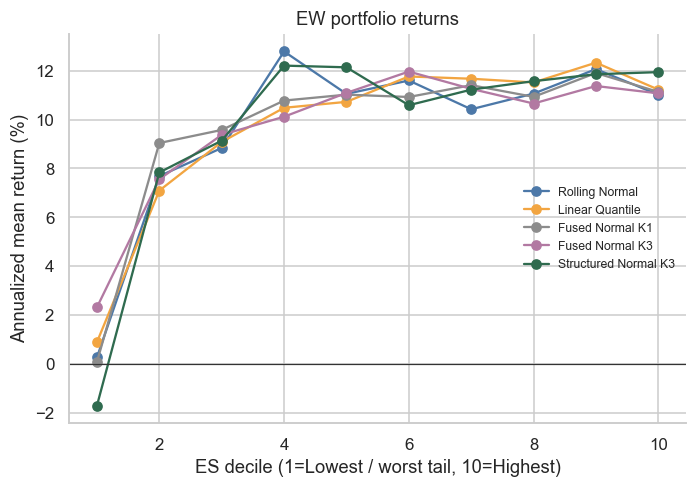

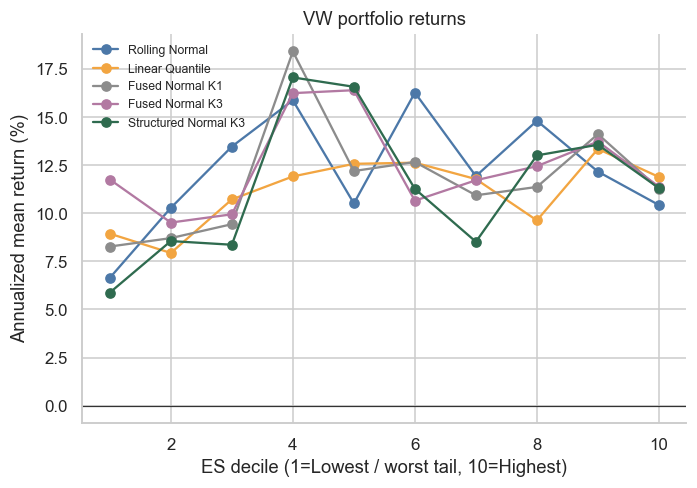

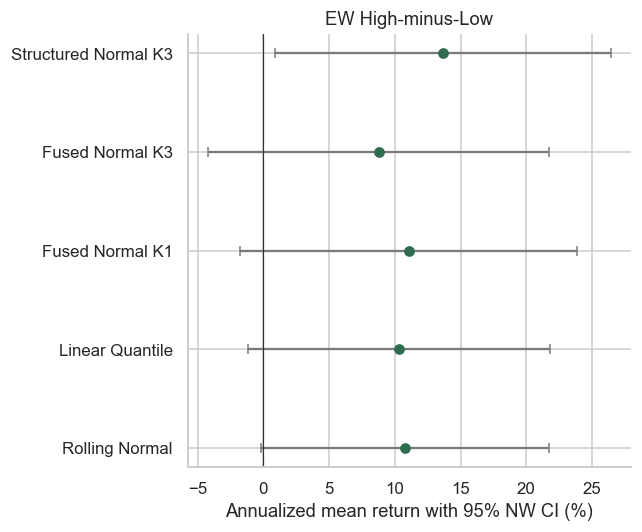

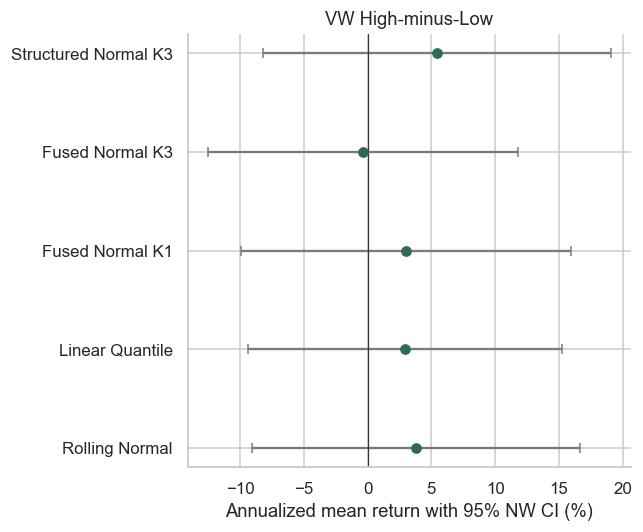

In [12]:
# ==========================================
# 4.2 图：组合单调性与 H-L 置信区间
# ==========================================

portfolio_means = primary_portfolios.groupby(["model_id", "model_label", "portfolio"], as_index=False
)[["ew_return", "vw_return"]].mean()


# 分别生成 EW、VW 组合收益图
for weighting in ["ew", "vw"]:
    fig, ax = plt.subplots(figsize=(6.5, 4.6))

    for model_id in model_order:
        data = portfolio_means[portfolio_means["model_id"] == model_id]
        ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                color=model_colors[model_id], label=model_labels[model_id])

    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting.upper()} portfolio returns",
        xlabel="ES decile (1=Lowest / worst tail, 10=Highest)",
           ylabel="Annualized mean return (%)")
    ax.legend(frameon=False, fontsize=8)

    # fig.suptitle(, y=1.03)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig01_model_portfolio_curves_{weighting}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
    # print(f"title={weighting.upper()} portfolio returns")
    # print(f"{int(PRIMARY_ALPHA * 100)}% return-ES portfolio returns: 2007–2024 signal months")
    fig.show()


# 分别生成 EW、VW High-minus-Low 置信区间图
for weighting in ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))

    data = primary_hml_summary[
        primary_hml_summary["weighting"] == weighting
    ].set_index("model_id").loc[model_order].reset_index()

    y = np.arange(len(data))

    ax.errorbar(
        data["annualized_mean_pct"], y,
        xerr=[data["annualized_mean_pct"] - data["annualized_ci_low_pct"],
              data["annualized_ci_high_pct"] - data["annualized_mean_pct"]],
        fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
    )

    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} High-minus-Low",
           xlabel="Annualized mean return with 95% NW CI (%)",
           yticks=y, yticklabels=data["model_label"])

    fig.tight_layout()
    fig.savefig(figure_dir / f"fig02_model_hml_intervals_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
    # print(f"title={weighting} High-minus-Low")
    # print(f"Tail-risk premium across forecasting models")
    fig.show()

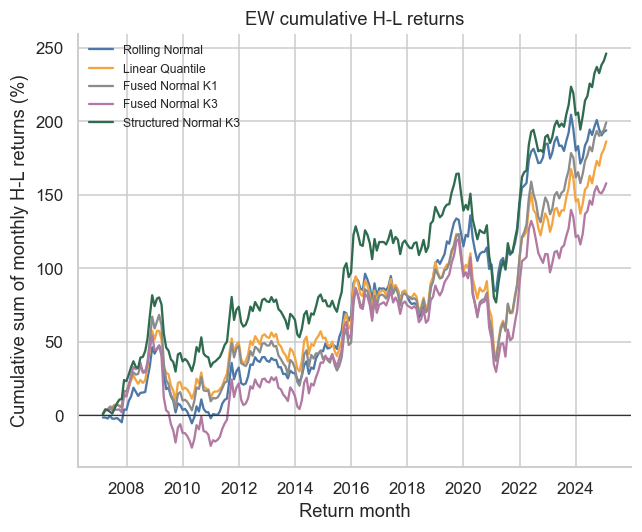

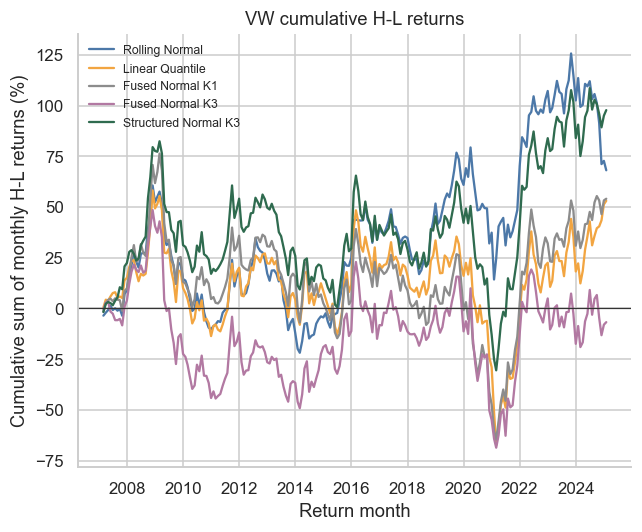

In [13]:
# ==========================================
# 4.3 图：H-L 累计收益和模型比较
# ==========================================

for weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    for model_id in model_order:
        data = primary_hml[(primary_hml["model_id"] == model_id) & (primary_hml["weighting"] == weighting)].sort_values("return_date")
        ax.plot(data["return_date"], 100 * data["hml_return"].cumsum(), color=model_colors[model_id], label=model_labels[model_id])
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(
        title=f"{weighting} cumulative H-L returns",
        xlabel="Return month", ylabel="Cumulative sum of monthly H-L returns (%)")
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig03_model_hml_cumulative_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
    # print(f"title={weighting} cumulative H-L returns")
    # print("Cumulative High-ES minus Low-ES returns")
    # fig.show()

## 5. Structured ES 的经济分解

以下比较总 ES、adverse component 对总 ES 的精确贡献(contribution)，以及 adverse component 在总体 VaR 阈值以下的条件平均收益(severity)。`pi_adverse` 是同月共同变量，不能用于月内股票排序。

`contribution = tail_weight × severity`，各 component contribution 加总为总 ES；数值越低表示尾部收益越差。severity 保留历史列名，但不再表示正数损失额。


In [14]:
# ==========================================
# 5.1 Adverse contribution 与 severity 组合
# ==========================================
mechanism_specs = {
    "Adverse contribution": "es_contribution_adverse_5",
    "Adverse severity": "severity_adverse_5",
}
mechanism_portfolio_parts, mechanism_hml_parts = [], []

for signal_name, signal_col in mechanism_specs.items():
    portfolios = sort_portfolios(pricing_base, signal_col, PRIMARY_GROUPS, me_breakpoints, exclude_microcaps, breakpoint_universe=breakpoint_universe,)
    metadata = {
        "model_id": "structured_normal_k3", "model_label": model_labels["structured_normal_k3"], "signal_name": signal_name,
        "n_groups": PRIMARY_GROUPS, "exclude_microcaps": exclude_microcaps, "breakpoint_universe": breakpoint_universe,
    }
    for key, value in metadata.items():
        portfolios[key] = value
    mechanism_portfolio_parts.append(portfolios)
    mechanism_hml_parts.append(build_hml(portfolios, metadata))

mechanism_portfolios = pd.concat(mechanism_portfolio_parts, ignore_index=True)
mechanism_hml = pd.concat(mechanism_hml_parts, ignore_index=True)
mechanism_hml_summary = summarize_hml(mechanism_hml)

full_portfolios = pd.concat([primary_portfolios, mechanism_portfolios], ignore_index=True)
full_hml = pd.concat([primary_hml, mechanism_hml], ignore_index=True)
full_hml_summary = pd.concat([primary_hml_summary, mechanism_hml_summary], ignore_index=True)

full_portfolios.to_parquet(result_dir / f"full_portfolios_{timestamp}.parquet", index=False)
full_hml.to_parquet(result_dir / f"full_hml_{timestamp}.parquet", index=False)
full_hml_summary.to_parquet(result_dir / f"full_hml_summary_{timestamp}.parquet", index=False)

display(full_portfolios)
display(full_hml)
display(full_hml_summary)

# structured_total_portfolios = primary_portfolios[primary_portfolios["model_id"] == "structured_normal_k3"].copy()
# structured_total_hml = primary_hml[primary_hml["model_id"] == "structured_normal_k3"].copy()
# structured_portfolios = pd.concat([structured_total_portfolios, mechanism_portfolios], ignore_index=True)
# structured_hml = pd.concat([structured_total_hml, mechanism_hml], ignore_index=True)

# display(pd.concat([structured_portfolios.head(),structured_portfolios.tail()]))
# display(pd.concat([structured_hml.head(),structured_hml.tail()]))

# display(pd.concat([
#     primary_hml_summary[primary_hml_summary["model_id"] == "structured_normal_k3"],
#     mechanism_hml_summary,
# ], ignore_index=True)[["signal_name", "weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))

,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.498512,0.015403,2.458294e+08,0.019654,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.330116,-0.005509,3.713619e+08,-0.010154,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.280647,0.002432,4.805910e+08,0.008914,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.244396,0.013930,9.235806e+08,-0.011002,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.213879,0.006531,7.503743e+08,-0.004591,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,2024-12-31,2025-01-31,6,206,-0.203979,0.036816,1.679180e+09,0.046333,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15116,2024-12-31,2025-01-31,7,205,-0.183313,0.027683,6.615805e+09,-0.048236,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15117,2024-12-31,2025-01-31,8,205,-0.162653,0.030012,4.276883e+09,0.087439,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15118,2024-12-31,2025-01-31,9,205,-0.145212,0.027189,7.842960e+09,0.040223,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.013708,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-02-28,2007-03-31,-0.000363,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-03-31,2007-04-30,-0.006502,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-04-30,2007-05-31,0.018556,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-05-31,2007-06-30,-0.019893,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
3019,2024-08-31,2024-09-30,-0.020675,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3020,2024-09-30,2024-10-31,-0.048260,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3021,2024-10-31,2024-11-30,-0.013919,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3022,2024-11-30,2024-12-31,0.055427,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,10,False,All,0.009219,0.005452,1.690809,0.090873,-0.001468,0.019905,216,11.062483,-1.761243,23.886208
1,fused_normal_k1,Fused Normal K1,Total ES (10%),VW,10,False,All,0.002503,0.005483,0.456508,0.648025,-0.008244,0.013250,216,3.003661,-9.892439,15.899761
2,fused_normal_k3,Fused Normal K3,Total ES (10%),EW,10,False,All,0.007305,0.005524,1.322358,0.186049,-0.003522,0.018132,216,8.765861,-4.226901,21.758623
3,fused_normal_k3,Fused Normal K3,Total ES (10%),VW,10,False,All,-0.000313,0.005166,-0.060531,0.951733,-0.010438,0.009813,216,-0.375253,-12.525996,11.775489
4,linear_quantile,Linear Quantile,Total ES (10%),EW,10,False,All,0.008621,0.004887,1.764175,0.077703,-0.000957,0.018199,216,10.345068,-1.148312,21.838448
5,linear_quantile,Linear Quantile,Total ES (10%),VW,10,False,All,0.002455,0.005237,0.468802,0.639211,-0.007809,0.012720,216,2.946132,-9.371271,15.263535
6,rolling_normal,Rolling Normal,Total ES (10%),EW,10,False,All,0.008968,0.004662,1.923556,0.054410,-0.000170,0.018106,216,10.761710,-0.203895,21.727315
7,rolling_normal,Rolling Normal,Total ES (10%),VW,10,False,All,0.003153,0.005468,0.576586,0.564219,-0.007564,0.013869,216,3.783036,-9.076717,16.642789
8,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.011387,0.005440,2.092941,0.036354,0.000723,0.022050,216,13.663929,0.867914,26.459943
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,10,False,All,0.004525,0.005807,0.779101,0.435920,-0.006858,0.015907,216,5.429458,-8.229541,19.088457


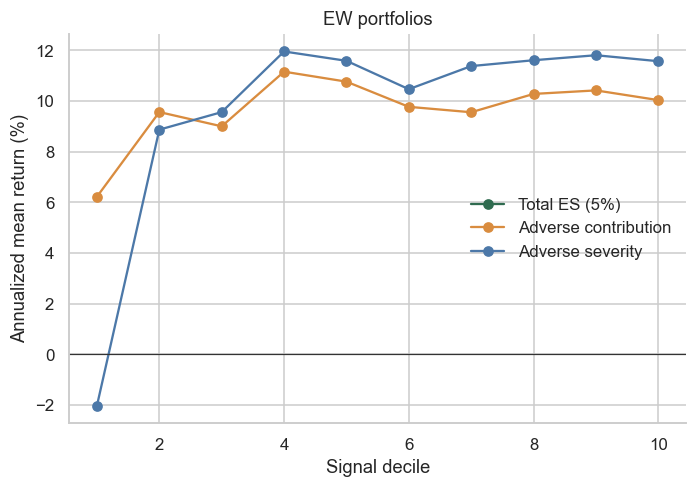

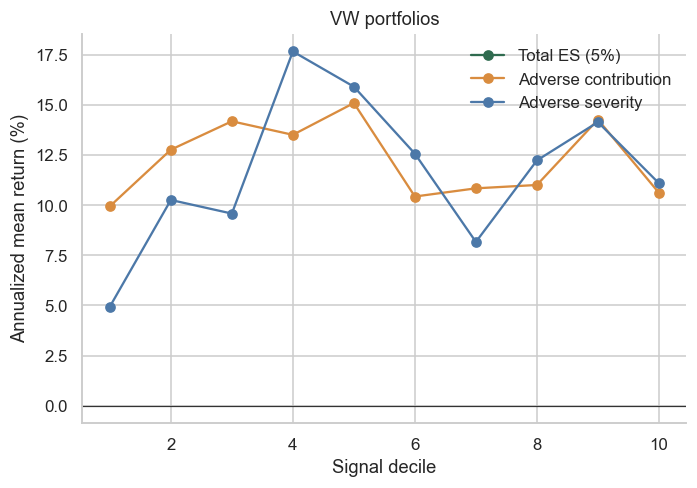

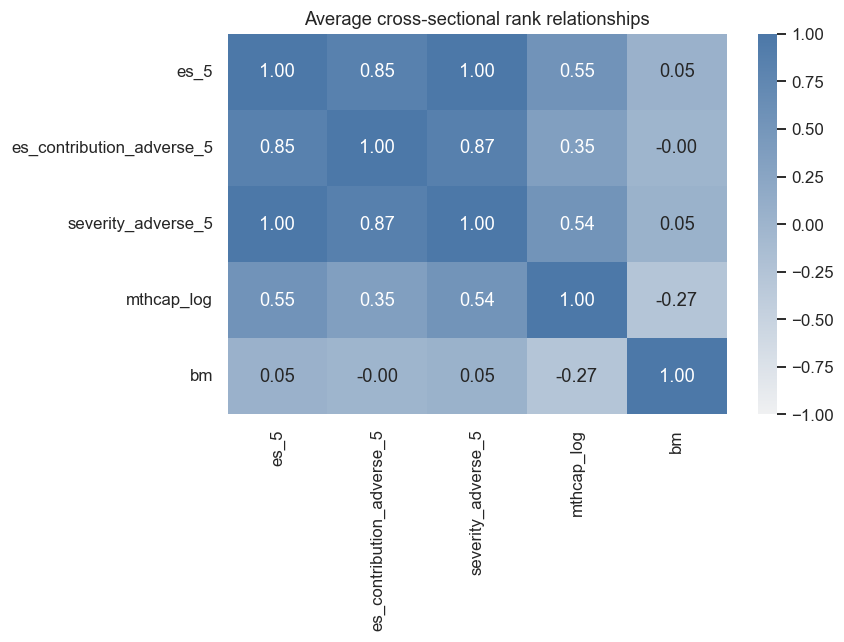

In [15]:
# ==========================================
# 5.2 图：Structured signals 的组合收益与相关性
# ==========================================
structured_portfolios = full_portfolios[full_portfolios["model_id"] == "structured_normal_k3"].copy()
structured_means = structured_portfolios.groupby(["signal_name", "portfolio"], as_index=False)[["ew_return", "vw_return"]].mean()

for weighting in  ["ew", "vw"]:
    fig, ax = plt.subplots(figsize=(6.5, 4.6))
    for signal_name in signal_colors:
        data = structured_means[structured_means["signal_name"] == signal_name]
        ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                color=signal_colors[signal_name], label=signal_name)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting.upper()} portfolios", xlabel="Signal decile", ylabel="Annualized mean return (%)")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig04_structured_signal_portfolios_{weighting}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

corr_cols = ["es_5", "es_contribution_adverse_5", "severity_adverse_5", "mthcap_log", "bm"]
ranked = pricing_base.groupby("mthcaldt")[corr_cols].rank(pct=True)
signal_correlation = ranked.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(signal_correlation, annot=True, fmt=".2f", cmap=sns.light_palette("#4C78A8", as_cmap=True), vmin=-1, vmax=1, ax=ax)
ax.set_title("Average cross-sectional rank relationships")
fig.tight_layout()
fig.savefig(figure_dir / f"fig05_signal_correlation.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

## 6. 因子调整 alpha

H–L 是零成本组合，因此不减 risk-free rate。组合收益使用下一月日期与 CAPM、FF3、Carhart4、FF5 和 FF5+Momentum 因子对齐。

In [16]:
# ==========================================
# 6.1 H-L factor regressions
# ==========================================
factor_models = {
    "CAPM": ["mktrf_ff3"],
    "FF3": ["mktrf_ff3", "smb_ff3", "hml_ff3"],
    "Carhart4": ["mktrf_ff3", "smb_ff3", "hml_ff3", "umd_ff3"],
    "FF5": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5"],
    "FF5+MOM": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5", "umd_ff5"],
}


def run_factor_regressions(hml):
    alpha_rows, coefficient_rows = [], []
    group_cols = ["model_id", "model_label", "signal_name", "weighting"]
    for keys, group in hml.groupby(group_cols):
        data = group.merge(factor_data, on="return_date", how="inner")
        for specification, factors in factor_models.items():
            regression = data[["hml_return"] + factors].dropna()
            fit = sm.OLS(regression["hml_return"], sm.add_constant(regression[factors])).fit(
                cov_type="HAC", cov_kwds={"maxlags": min(NW_LAGS, len(regression) - 1)}
            )
            ci = fit.conf_int().loc["const"]
            row = dict(zip(group_cols, keys))
            row.update({
                "specification": specification, "alpha_monthly": fit.params["const"],
                "alpha_annualized_pct": 1200 * fit.params["const"], "nw_t": fit.tvalues["const"],
                "p_value": fit.pvalues["const"], "ci_95_low_pct": 1200 * ci.iloc[0],
                "ci_95_high_pct": 1200 * ci.iloc[1], "r_squared": fit.rsquared, "months": int(fit.nobs),
            })
            alpha_rows.append(row)
            for parameter in fit.params.index:
                coefficient_rows.append({**row, "parameter": parameter, "coefficient": fit.params[parameter], "parameter_t": fit.tvalues[parameter]})
    return pd.DataFrame(alpha_rows), pd.DataFrame(coefficient_rows)

factor_alphas, factor_coefficients = run_factor_regressions(full_hml)
# display(factor_alphas[factor_alphas["specification"] == "FF5+MOM"][[
#     "model_label", "signal_name", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
# ]].round(4))

# display(factor_alphas[[
#     "model_label", "signal_name", "specification", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
# ]].round(4))

factor_alphas.to_parquet(result_dir / f"factor_alphas_{timestamp}.parquet", index=False)
factor_coefficients.to_parquet(result_dir / f"factor_coefficients_{timestamp}.parquet", index=False)

display(factor_alphas)
display(factor_coefficients)

,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.015393,18.471245,3.382445,0.000718,7.768047,29.174443,0.213393,216
1,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.013180,15.816335,4.210931,0.000025,8.454674,23.177996,0.557164,216
2,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,Carhart4,0.012533,15.040076,4.090691,0.000043,7.833956,22.246196,0.573609,216
3,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF5,0.007514,9.016305,2.824039,0.004742,2.758730,15.273879,0.683910,216
4,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF5+MOM,0.006948,8.338015,2.759251,0.005793,2.415318,14.260712,0.698928,216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,CAPM,0.011996,14.395792,2.657217,0.007879,3.777452,25.014133,0.274947,216
66,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF3,0.009460,11.352543,2.806895,0.005002,3.425430,19.279657,0.617718,216
67,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,Carhart4,0.009188,11.026035,2.718357,0.006561,3.076148,18.975922,0.620277,216
68,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5,0.003892,4.670335,1.576746,0.114854,-1.135094,10.475764,0.731662,216


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months,parameter,coefficient,parameter_t
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.015393,18.471245,3.382445,0.000718,7.768047,29.174443,0.213393,216,const,0.015393,3.382445
1,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.015393,18.471245,3.382445,0.000718,7.768047,29.174443,0.213393,216,mktrf_ff3,-0.733500,-5.862735
2,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.013180,15.816335,4.210931,0.000025,8.454674,23.177996,0.557164,216,const,0.013180,4.210931
3,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.013180,15.816335,4.210931,0.000025,8.454674,23.177996,0.557164,216,mktrf_ff3,-0.457228,-3.470802
4,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.013180,15.816335,4.210931,0.000025,8.454674,23.177996,0.557164,216,smb_ff3,-1.791024,-10.074326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.003642,4.370871,1.450244,0.146990,-1.536238,10.277981,0.734238,216,smb_ff5,-1.468193,-13.011764
332,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.003642,4.370871,1.450244,0.146990,-1.536238,10.277981,0.734238,216,hml_ff5,0.520312,3.597293
333,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.003642,4.370871,1.450244,0.146990,-1.536238,10.277981,0.734238,216,rmw_ff5,1.488334,9.254182
334,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.003642,4.370871,1.450244,0.146990,-1.536238,10.277981,0.734238,216,cma_ff5,0.070439,0.396214


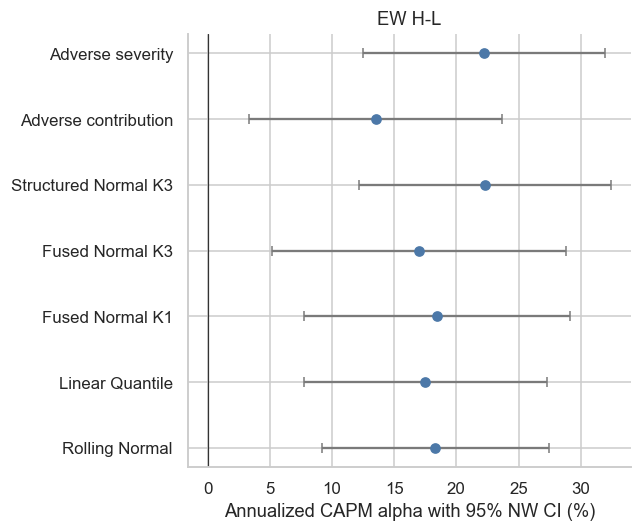

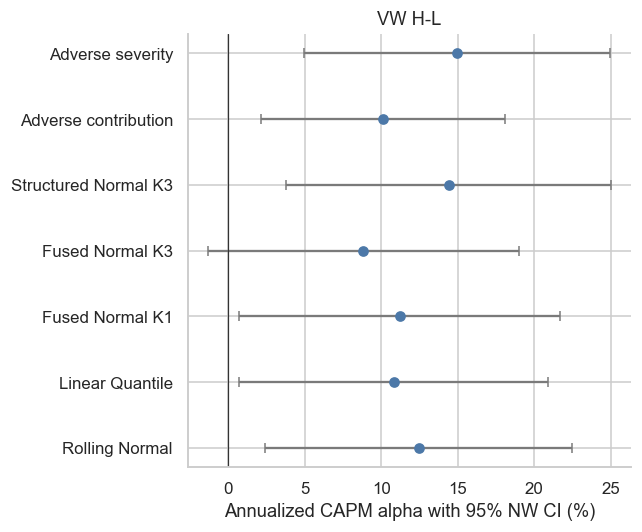

In [17]:
specification_FF="CAPM"
plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)


series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
for  weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} H-L", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
    # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


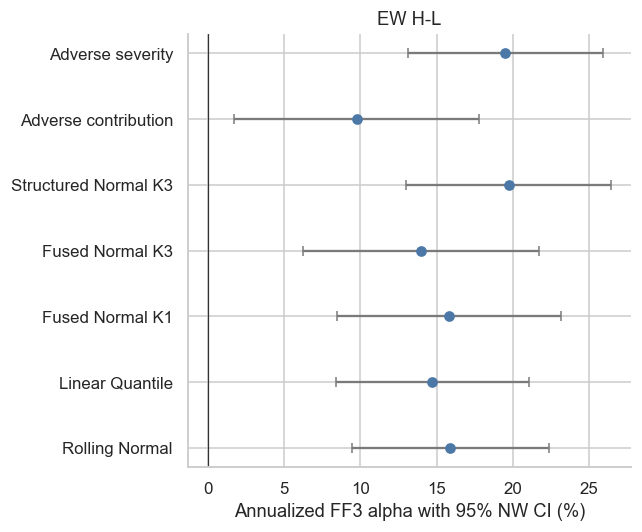

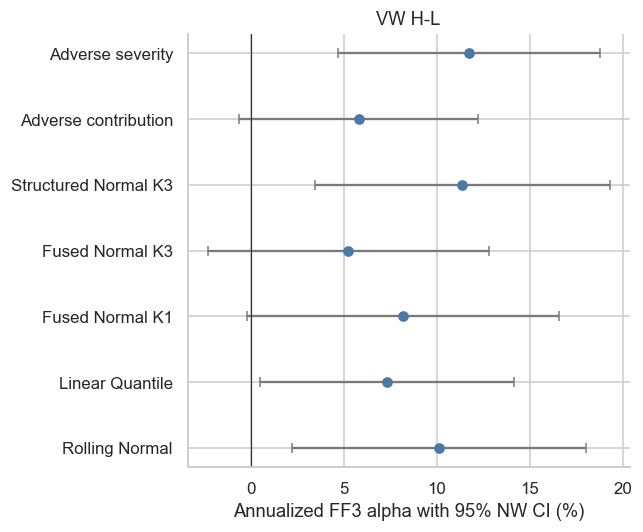

In [18]:
specification_FF="FF3"
plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)

for  weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} H-L", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
    # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

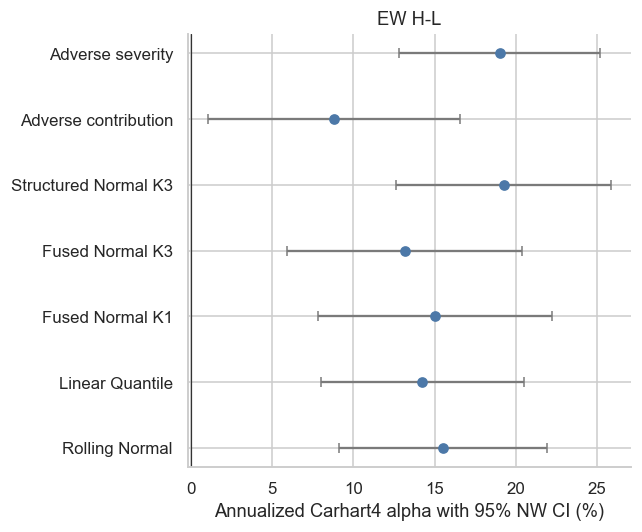

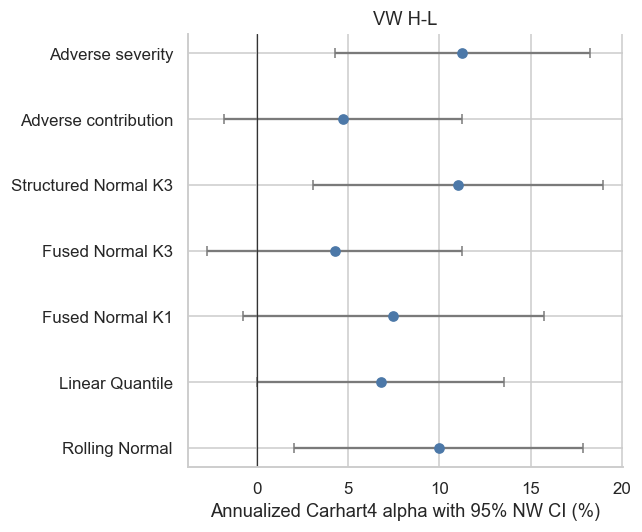

In [19]:
specification_FF="Carhart4"
plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)

for  weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} H-L", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
    # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
    # save_figure(fig, f"fig06_factor_adjusted_alpha_{specification_FF.lower()}")

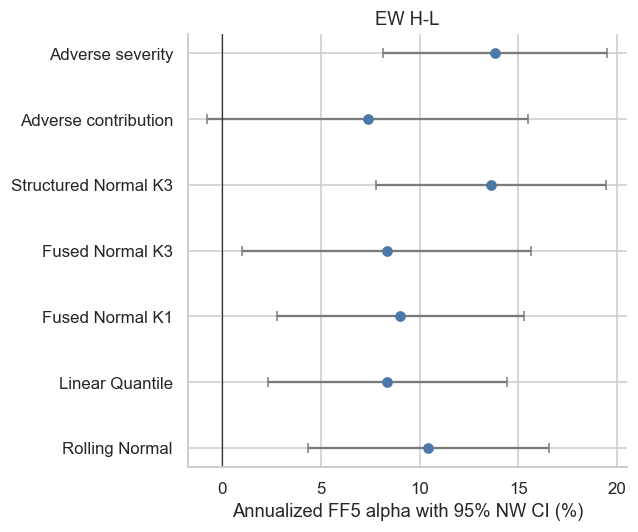

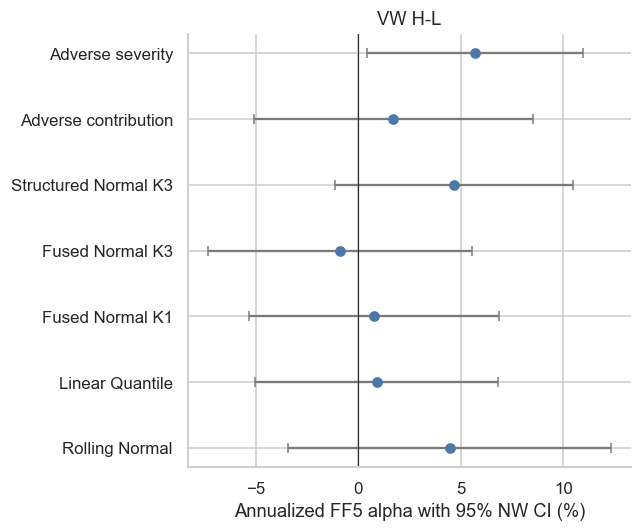

In [20]:
specification_FF="FF5"
plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)
for  weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    ax.set(title=f"{weighting} H-L", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
    # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

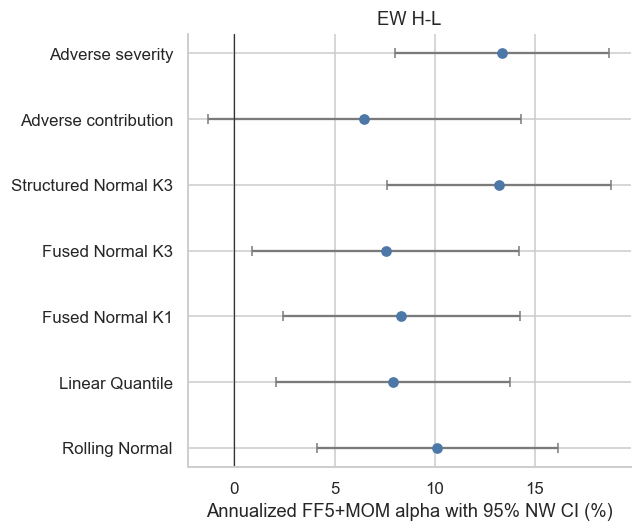

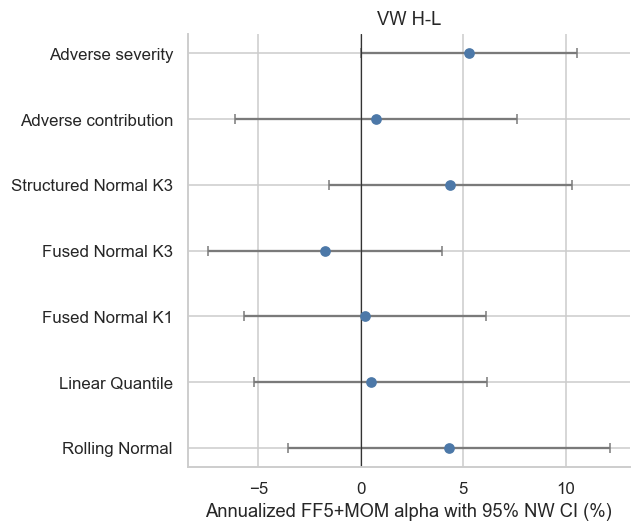

In [21]:
specification_FF="FF5+MOM"
plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
plot_alpha["series_label"] = np.where(
    plot_alpha["signal_name"] == f"Total ES ({int(PRIMARY_ALPHA * 100)}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
)
for  weighting in  ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
    y = np.arange(len(data))
    ax.errorbar(
        data["alpha_annualized_pct"], y,
        xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
        fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
    )
    ax.axvline(0, color="#333333", linewidth=0.8)
    # 
    ax.set(title=f"{weighting} H-L", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
    # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
    # save_figure(fig, f"fig06_factor_adjusted_alpha_{specification_FF.lower()}")

## 7. Fama–MacBeth 横截面回归

连续变量每月先在 1%/99% winsorize，再标准化。所有规格使用相同的 non-missing control sample：

1. Univariate；
2. Controls：size、book-to-market、momentum、历史波动率；
3. Controls + FF49 industry fixed effects。

In [22]:
control_cols = ["mthcap_log", "bm", "MOM12m", "mu_bench", "sigma_bench", "turnover"]

In [23]:
# ==========================================
# 7.1 月度横截面回归函数
# ==========================================
def standardize_monthly(panel, columns):
    result = panel.copy()
    for column in columns:
        grouped = result.groupby("mthcaldt")[column]
        lower = grouped.transform(lambda x: x.quantile(0.01))
        upper = grouped.transform(lambda x: x.quantile(0.99))
        clipped = result[column].clip(lower=lower, upper=upper)
        mean = clipped.groupby(result["mthcaldt"]).transform("mean")
        std = clipped.groupby(result["mthcaldt"]).transform("std")
        result[f"z_{column}"] = (clipped - mean) / std
    return result


def run_fama_macbeth(panel, signal_col, model_id, model_label, signal_name):
    required = ["mthcaldt", "target_ret_final", industry_type, signal_col, *control_cols]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work = standardize_monthly(work, [signal_col, *control_cols])
    z_signal = f"z_{signal_col}"
    z_controls = [f"z_{column}" for column in control_cols]
    specifications = {
        "Univariate": ([], False), "Controls": (z_controls, False),
        "Controls+IndustryFE": (z_controls, True),
    }

    rows = []
    for month, group in work.groupby("mthcaldt", sort=True):
        y = group["target_ret_final"].to_numpy(dtype=float)
        for specification, (controls, industry_fe) in specifications.items():
            X = group[[z_signal] + controls].to_numpy(dtype=float)
            if industry_fe:
                industry = pd.get_dummies(group[industry_type].astype(int), drop_first=True, dtype=float).to_numpy()
                X = np.column_stack([X, industry])
            X = np.column_stack([np.ones(len(group)), X])
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            residual = y - X @ beta
            total_ss = np.sum((y - y.mean()) ** 2)
            rows.append({
                "mthcaldt": month, "model_id": model_id, "model_label": model_label,
                "signal_name": signal_name, "specification": specification,
                "signal_slope": beta[1], "r_squared": 1 - np.sum(residual ** 2) / total_ss,
                "n_firms": len(group),
            })
    return pd.DataFrame(rows)


def summarize_fama_macbeth(slopes):
    rows = []
    group_cols = ["model_id", "model_label", "signal_name", "specification"]
    for keys, group in slopes.groupby(group_cols):
        row = dict(zip(group_cols, keys))
        row.update(nw_mean(group["signal_slope"]))
        row["annualized_slope_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

In [24]:
# ==========================================
# 7.2 所有模型 ES、adverse contribution 和 severity
# ==========================================
fmb_parts = []
for model_id in model_order:
    print("Fama-MacBeth:", model_labels[model_id])
    panel = load_model_panel(model_id, PRIMARY_ALPHA)
    fmb_parts.append(run_fama_macbeth(panel, "signal", model_id, model_labels[model_id], "Total ES (5%)"))

for signal_name, signal_col in mechanism_specs.items():
    print("Fama-MacBeth:", signal_name)
    fmb_parts.append(run_fama_macbeth(pricing_base, signal_col, "structured_normal_k3", signal_name, signal_name))

fmb_monthly_slopes = pd.concat(fmb_parts, ignore_index=True)
fmb_summary = summarize_fama_macbeth(fmb_monthly_slopes)

fmb_monthly_slopes.to_parquet(result_dir / f"fmb_monthly_slopes_{timestamp}.parquet", index=False)
fmb_summary.to_parquet(result_dir / f"fmb_summary_{timestamp}.parquet", index=False)

display(fmb_monthly_slopes)
display(fmb_summary)


Fama-MacBeth: Rolling Normal
Fama-MacBeth: Linear Quantile
Fama-MacBeth: Fused Normal K1
Fama-MacBeth: Fused Normal K3
Fama-MacBeth: Structured Normal K3
Fama-MacBeth: Adverse contribution
Fama-MacBeth: Adverse severity


,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms
0,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Univariate,-0.001676,0.000302,2692
1,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls,-0.003084,0.010126,2692
2,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls+IndustryFE,-0.003465,0.021240,2692
3,2007-02-28,rolling_normal,Rolling Normal,Total ES (5%),Univariate,0.002720,0.000791,2689
4,2007-02-28,rolling_normal,Rolling Normal,Total ES (5%),Controls,-0.000039,0.020214,2689
...,...,...,...,...,...,...,...,...
4531,2024-11-30,structured_normal_k3,Adverse severity,Adverse severity,Controls,0.001009,0.027421,1933
4532,2024-11-30,structured_normal_k3,Adverse severity,Adverse severity,Controls+IndustryFE,0.001713,0.066432,1933
4533,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Univariate,0.006186,0.002063,1904
4534,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls,-0.009436,0.024582,1904


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls,-0.000110,0.001557,-0.070959,0.943430,-0.003162,0.002941,216,-0.132589,-3.794898,3.529719
1,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls+IndustryFE,0.000499,0.001774,0.281073,0.778654,-0.002978,0.003976,216,0.598360,-3.574170,4.770890
2,fused_normal_k1,Fused Normal K1,Total ES (5%),Univariate,0.001999,0.001565,1.277553,0.201407,-0.001068,0.005066,216,2.398794,-1.281396,6.078983
3,fused_normal_k3,Fused Normal K3,Total ES (5%),Controls,-0.000188,0.001338,-0.140208,0.888496,-0.002811,0.002435,216,-0.225159,-3.372705,2.922387
4,fused_normal_k3,Fused Normal K3,Total ES (5%),Controls+IndustryFE,0.000539,0.001586,0.339751,0.734044,-0.002570,0.003648,216,0.646697,-3.084049,4.377442
5,fused_normal_k3,Fused Normal K3,Total ES (5%),Univariate,0.002043,0.001569,1.302177,0.192856,-0.001032,0.005119,216,2.452092,-1.238728,6.142912
6,linear_quantile,Linear Quantile,Total ES (5%),Controls,0.000535,0.001202,0.445270,0.656125,-0.001821,0.002891,216,0.642314,-2.185039,3.469668
7,linear_quantile,Linear Quantile,Total ES (5%),Controls+IndustryFE,0.000980,0.001389,0.705237,0.480663,-0.001743,0.003703,216,1.175761,-2.091922,4.443444
8,linear_quantile,Linear Quantile,Total ES (5%),Univariate,0.002258,0.001480,1.525671,0.127092,-0.000643,0.005159,216,2.709600,-0.771370,6.190569
9,rolling_normal,Rolling Normal,Total ES (5%),Controls,0.001815,0.000798,2.274134,0.022958,0.000251,0.003379,216,2.177583,0.300797,4.054369


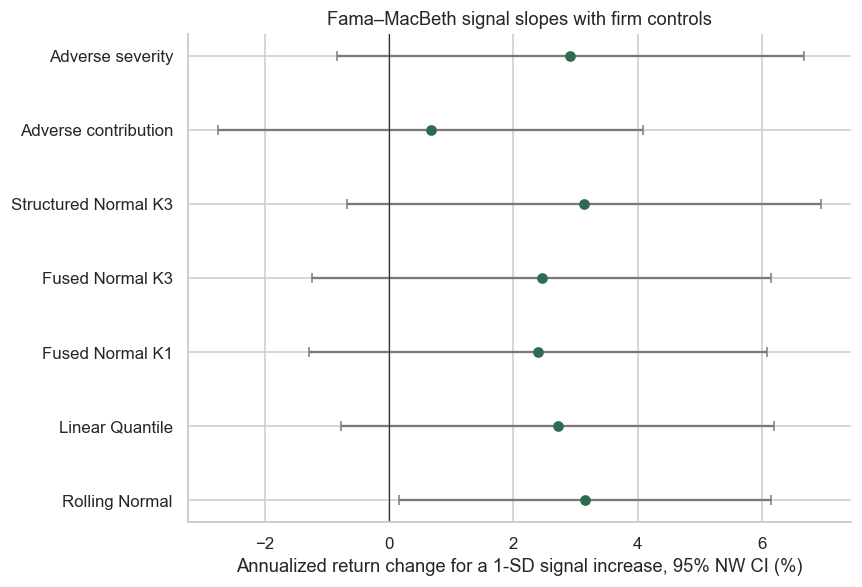

In [25]:
# ==========================================
# 7.3 图：Fama-MacBeth slopes
# ==========================================
plot_fmb = fmb_summary[fmb_summary["specification"] == "Univariate"].copy()
plot_fmb["series_label"] = plot_fmb["model_label"]
series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
plot_fmb = plot_fmb.set_index("series_label").reindex(series_order).dropna().reset_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(plot_fmb))
ax.errorbar(
    plot_fmb["annualized_slope_pct"], y,
    xerr=[plot_fmb["annualized_slope_pct"] - plot_fmb["annualized_ci_low_pct"], plot_fmb["annualized_ci_high_pct"] - plot_fmb["annualized_slope_pct"]],
    fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(
    title="Fama–MacBeth signal slopes with firm controls",
    xlabel="Annualized return change for a 1-SD signal increase, 95% NW CI (%)",
    yticks=y, yticklabels=plot_fmb["series_label"],
)
fig.tight_layout()
fig.savefig(figure_dir / f"fig07_fama_macbeth_univariate.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


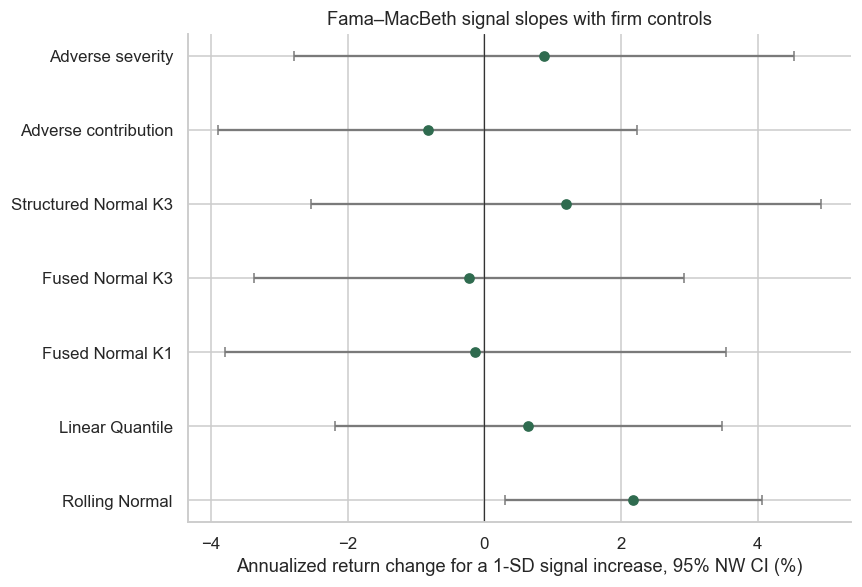

In [26]:
# ==========================================
# 7.3 图：控制变量后的 Fama-MacBeth slopes
# ==========================================
plot_fmb = fmb_summary[fmb_summary["specification"] == "Controls"].copy()
plot_fmb["series_label"] = plot_fmb["model_label"]
series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
plot_fmb = plot_fmb.set_index("series_label").reindex(series_order).dropna().reset_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(plot_fmb))
ax.errorbar(
    plot_fmb["annualized_slope_pct"], y,
    xerr=[plot_fmb["annualized_slope_pct"] - plot_fmb["annualized_ci_low_pct"], plot_fmb["annualized_ci_high_pct"] - plot_fmb["annualized_slope_pct"]],
    fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(
    title="Fama–MacBeth signal slopes with firm controls",
    xlabel="Annualized return change for a 1-SD signal increase, 95% NW CI (%)",
    yticks=y, yticklabels=plot_fmb["series_label"],
)
fig.tight_layout()
fig.savefig(figure_dir / f"fig07_fama_macbeth_controls.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02) 

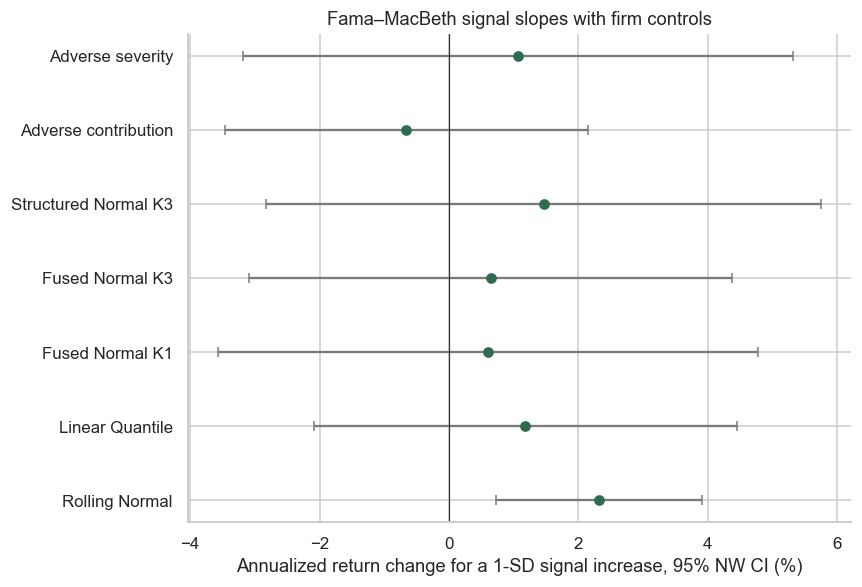

In [27]:
# ==========================================
# 7.3 图：控制变量和行业固定效应下的 Fama-MacBeth slopes
# ==========================================
plot_fmb = fmb_summary[fmb_summary["specification"] == "Controls+IndustryFE"].copy()
plot_fmb["series_label"] = plot_fmb["model_label"]
series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
plot_fmb = plot_fmb.set_index("series_label").reindex(series_order).dropna().reset_index()

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(plot_fmb))
ax.errorbar(
    plot_fmb["annualized_slope_pct"], y,
    xerr=[plot_fmb["annualized_slope_pct"] - plot_fmb["annualized_ci_low_pct"], plot_fmb["annualized_ci_high_pct"] - plot_fmb["annualized_slope_pct"]],
    fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(
    title="Fama–MacBeth signal slopes with firm controls",
    xlabel="Annualized return change for a 1-SD signal increase, 95% NW CI (%)",
    yticks=y, yticklabels=plot_fmb["series_label"],
)
fig.tight_layout()
fig.savefig(figure_dir / f"fig07_fama_macbeth_controls_industry_fe.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02) 

## 8. Adverse weight 与 severity premium

`pi_adverse` 是每个月共同的 adverse-component probability，
不参与股票的月内横截面排序。

本节的主检验使用全样本标准化的连续 `pi_adverse`，检验：

1. H–L portfolio return 是否随 global adverse weight 变化；
2. 月度 Fama–MacBeth severity slope 是否随 global adverse weight 变化；
3. 个股层 severity × adverse-weight interaction 是否显著。

为展示经济量级，另外比较全样本 `pi_adverse` 最高三分之一和
最低三分之一的月份。加入 window fixed effects 或使用 within-window
standardization 的结果仅作为稳健性检验。

In [28]:
# ==========================================
# 8.1 构造 global adverse-weight state
# ==========================================
state_monthly = (pricing_base.groupby("mthcaldt",as_index=False,)
    .agg(pi_adverse=("pi_adverse", "first"), window=("window", "first"),)
    .sort_values("mthcaldt").reset_index(drop=True)
)

# 主状态变量：全样本标准化
pi_mean = state_monthly["pi_adverse"].mean()
pi_std = state_monthly["pi_adverse"].std(ddof=1)
state_monthly["pi_adverse_global_z"] = (state_monthly["pi_adverse"] - pi_mean) / pi_std

# 全样本 percentile rank，用于图和状态分组
state_monthly["pi_rank_global"] = state_monthly["pi_adverse"].rank(pct=True)

# Within-window z-score 只保留为稳健性检验
window_mean = state_monthly.groupby("window")["pi_adverse"].transform("mean")
window_std = state_monthly.groupby("window")["pi_adverse"].transform("std", ddof=1)
state_monthly["pi_adverse_within_z"] = (state_monthly["pi_adverse"] - window_mean) / window_std

# 全样本最高/最低二分之一
cutoff_half = state_monthly["pi_adverse"].quantile(1 / 2)
state_monthly["adverse_state_global_half"] = np.select(
    [
        state_monthly["pi_adverse"] < cutoff_half,
        state_monthly["pi_adverse"] >= cutoff_half,
    ],
    [
        "Low global tercile",
        "High global tercile",
    ],
    default="Middle",
)

# 全样本最高/最低三分之一
low_cutoff_third = state_monthly["pi_adverse"].quantile(1 / 3)
high_cutoff_third = state_monthly["pi_adverse"].quantile(2 / 3)
state_monthly["adverse_state_global_third"] = np.select(
    [
        state_monthly["pi_adverse"] <= low_cutoff_third,
        state_monthly["pi_adverse"] >= high_cutoff_third,
    ],
    [
        "Low global tercile",
        "High global tercile",
    ],
    default="Middle",
)
state_monthly.to_parquet(result_dir / f"state_monthly_{timestamp}.parquet", index=False)
display(state_monthly)

,mthcaldt,pi_adverse,window,pi_adverse_global_z,pi_rank_global,pi_adverse_within_z,adverse_state_global_half,adverse_state_global_third
0,2007-01-31,0.528514,0,0.747089,0.722222,-0.671297,High global tercile,High global tercile
1,2007-02-28,0.751535,0,1.517642,0.898148,0.657035,High global tercile,High global tercile
2,2007-03-31,0.730182,0,1.443868,0.879630,0.529858,High global tercile,High global tercile
3,2007-04-30,0.657566,0,1.192974,0.810185,0.097349,High global tercile,High global tercile
4,2007-05-31,0.664239,0,1.216031,0.819444,0.137096,High global tercile,High global tercile
...,...,...,...,...,...,...,...,...
211,2024-08-31,0.510838,17,0.686018,0.694444,-0.265613,High global tercile,High global tercile
212,2024-09-30,0.470053,17,0.545103,0.675926,-0.508048,High global tercile,High global tercile
213,2024-10-31,0.346842,17,0.119399,0.601852,-1.240444,High global tercile,Middle
214,2024-11-30,0.477088,17,0.569408,0.680556,-0.466232,High global tercile,High global tercile


In [29]:
def continuous_hml_state_test(hml, state):
    # 回归模型: hml_return ~ pi_adverse_global_z + window FE (optional)
    rows = []
    group_cols = ["model_id", "model_label", "signal_name", "weighting",]

    for keys, group in hml.groupby(group_cols):
        merged = group.merge(state[["mthcaldt", "window", "pi_adverse_global_z",]],on="mthcaldt",validate="one_to_one",)

        for specification, state_col, add_window_fe in [("Global", "pi_adverse_global_z", False),
                                                        ("Global + window FE", "pi_adverse_global_z", True,),]:
            data = merged[["hml_return", state_col, "window",]].dropna().reset_index(drop=True)

            X = pd.DataFrame({"const": 1.0, state_col: data[state_col],})

            if add_window_fe:
                window_dummies = pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float,)
                X = pd.concat([X, window_dummies],axis=1,)

            fit = sm.OLS(data["hml_return"],X,).fit(
                cov_type="HAC",cov_kwds={"maxlags": min(NW_LAGS,len(data) - 1,)},)
            ci = fit.conf_int().loc[state_col]
            rows.append(
                {
                    **dict(zip(group_cols, keys)),
                    "state_specification": specification,
                    "state_variable": state_col,
                    "coefficient": fit.params[state_col],
                    "annualized_coefficient_pct": 1200 * fit.params[state_col],
                    "nw_t": fit.tvalues[state_col],
                    "p_value": fit.pvalues[state_col],
                    "ci_95_low_pct": 1200 * ci.iloc[0],
                    "ci_95_high_pct": 1200 * ci.iloc[1],
                    "months": int(fit.nobs),
                }
            )

    return pd.DataFrame(rows)

state_hml_continuous = continuous_hml_state_test(full_hml[full_hml["model_id"] == "structured_normal_k3"], state_monthly,)
state_hml_continuous.to_parquet(result_dir / f"state_hml_continuous_{timestamp}.parquet", index=False)
display(
    state_hml_continuous[
        [
            "signal_name",
            "weighting",
            "state_specification",
            "annualized_coefficient_pct",
            "nw_t",
            "p_value",
            "months",
        ]
    ].round(4)
)

,signal_name,weighting,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Adverse contribution,EW,Global,6.4272,1.1300,0.2585,216
1,Adverse contribution,EW,Global + window FE,13.9232,2.0308,0.0423,216
2,Adverse contribution,VW,Global,5.1042,0.9216,0.3567,216
3,Adverse contribution,VW,Global + window FE,13.3926,1.9029,0.0571,216
4,Adverse severity,EW,Global,-1.1900,-0.1952,0.8452,216
5,Adverse severity,EW,Global + window FE,4.1377,0.5298,0.5962,216
6,Adverse severity,VW,Global,-1.1969,-0.1961,0.8446,216
7,Adverse severity,VW,Global + window FE,7.5163,0.9296,0.3526,216
8,Total ES (10%),EW,Global,-0.9737,-0.1542,0.8774,216
9,Total ES (10%),EW,Global + window FE,4.0334,0.4976,0.6188,216


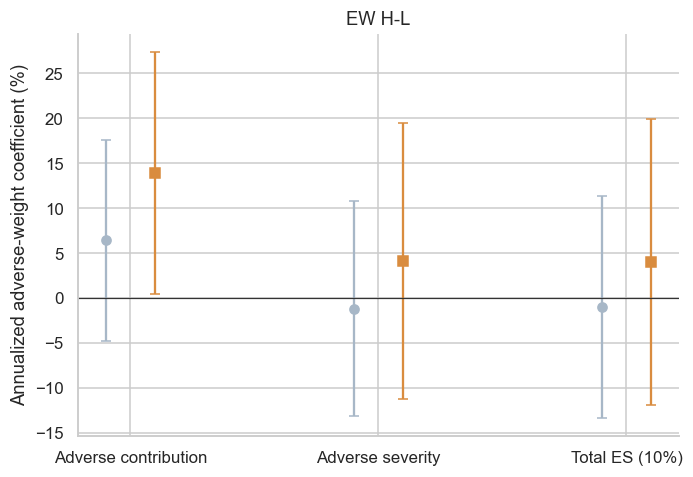

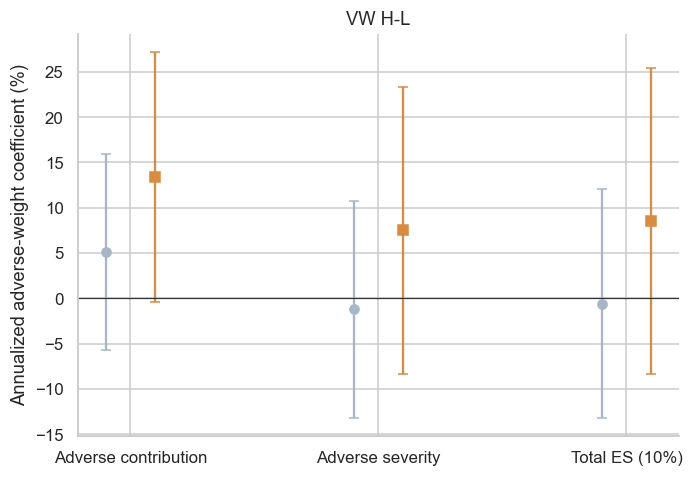

In [30]:

for weighting in ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))

    data = state_hml_continuous[
        state_hml_continuous["weighting"] == weighting
    ].copy()

    signals = ["Adverse contribution", "Adverse severity", f"Total ES ({PRIMARY_ALPHA*100:.0f}%)"]
    x = np.arange(len(signals))

    for offset, state_name, color, marker in [
        (-0.10, "Global", "#A7B7C7", "o"),
        (0.10, "Global + window FE", "#D98C3F", "s"),
    ]:

        state_data = (
            data[data["state_specification"] == state_name]
            .set_index("signal_name")
            .loc[signals]
        )

        ax.errorbar(
            x + offset,
            state_data["annualized_coefficient_pct"],
            yerr=[
                state_data["annualized_coefficient_pct"]
                - state_data["ci_95_low_pct"],
                state_data["ci_95_high_pct"]
                - state_data["annualized_coefficient_pct"],
            ],
            fmt=marker,
            color=color,
            capsize=3,
            label=state_name,
        )

    ax.axhline(0, color="#333333", linewidth=0.8)

    ax.set(
        title=f"{weighting} H-L",
        ylabel="Annualized adverse-weight coefficient (%)",
        xticks=x,
        xticklabels=signals,
        xlabel="",
    )
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig08_state_continuous_coefficients_{weighting}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

# axes[0].legend(frameon=False)
# fig.suptitle("Adverse-weight effects on component H-L premiums", y=1.03)



In [31]:
# ==========================================
# 8.3 月度 severity slope 对 adverse weight 的回归
# ==========================================
# 回归方程是: monthly_severity_slope = β0 + β1 * adverse_weight + ε
severity_slopes = fmb_monthly_slopes[
    (fmb_monthly_slopes["signal_name"] == "Adverse severity") &
    (fmb_monthly_slopes["specification"] == "Controls")
].merge(state_monthly, on="mthcaldt", validate="one_to_one")

rows = []

for state_spec, x_col, add_window_fe in [("Global", "pi_adverse_global_z", False,),
                                         ("Global + window FE", "pi_adverse_global_z", True,),]:
    X = pd.DataFrame({"const": 1.0, x_col: severity_slopes[x_col]})
    if add_window_fe:
        X = pd.concat([X, pd.get_dummies(severity_slopes["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
    fit_state = sm.OLS(severity_slopes["signal_slope"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
    rows.append({
        "dependent_variable": "monthly severity slope", "state_specification": state_spec,
        "coefficient_pi_adverse_z": fit_state.params[x_col], "nw_t": fit_state.tvalues[x_col],
        "p_value": fit_state.pvalues[x_col], "months": int(fit_state.nobs),
    })
state_slope_regression = pd.DataFrame(rows)
state_slope_regression.to_parquet(result_dir / f"state_slope_regression_{timestamp}.parquet", index=False)
display(state_slope_regression.round(6))

visual_data = severity_slopes[["signal_slope", "pi_adverse_global_z",]].dropna().copy()

fit_visual = sm.OLS(
    visual_data["signal_slope"],
    sm.add_constant(
        visual_data["pi_adverse_global_z"]
    ),
).fit()



,dependent_variable,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,monthly severity slope,Global,0.000105,0.083069,0.933797,216
1,monthly severity slope,Global + window FE,0.001521,0.814862,0.415151,216


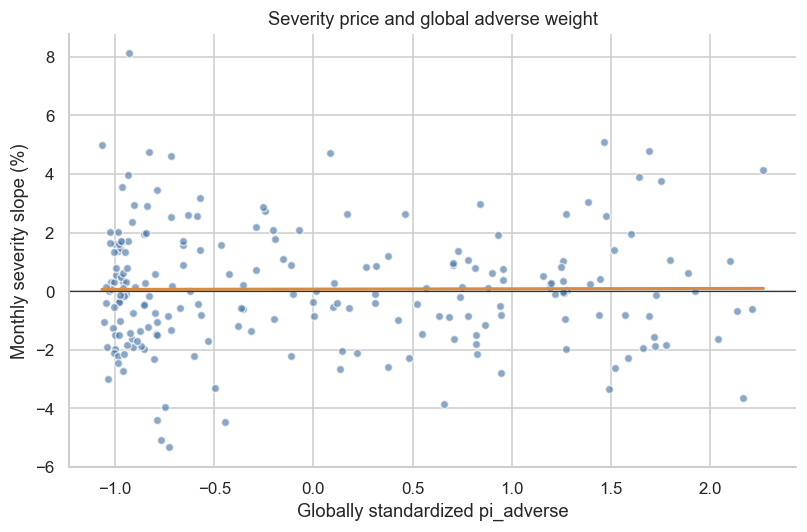

In [32]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter( visual_data["pi_adverse_global_z"], 100 * visual_data["signal_slope"], s=28, alpha=0.65, color="#4C78A8", edgecolor="white",)
x_line = np.linspace( visual_data["pi_adverse_global_z"].min(), visual_data["pi_adverse_global_z"].max(), 100,)
ax.plot( x_line, 100 * (  fit_visual.params["const"]  + fit_visual.params["pi_adverse_global_z"]  * x_line ), color="#D98C3F", linewidth=2,)
ax.axhline( 0, color="#333333", linewidth=0.8,)
ax.set( 
    title="Severity price and global adverse weight", 
    xlabel="Globally standardized pi_adverse", ylabel="Monthly severity slope (%)",)
fig.tight_layout()
fig.savefig(figure_dir / f"fig09_state_slope_scatter.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

# save_figure(fig, "fig09_state_slope_scatter")

In [33]:
def pooled_state_interaction(panel, signal_col, signal_name, state):
    # 这个函数用于在月度横截面回归中加入 adverse weight 的交互项，检验 adverse weight 对信号收益的调节作用。
    # 回归方程是: demeaned_return = β0 + β1 * z_signal + β2 * z_signal * adverse_weight + β3 * z_controls + ε
    # 这段代码的核心，是在运行一个带有交互项（Interaction Term）的面板数据回归模型。它的终极目的，是想回答一个量化投资/资产定价中的经典问题：
    # 当市场处于某种特定状态（比如“不利权重”很高时），某个预测信号（如严重程度信号）对股票收益率的预测能力，会不会发生显著的增强或减弱？
    required = ["mthcaldt", "target_ret_final", signal_col, *control_cols]
    
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work = standardize_monthly(work, [signal_col, *control_cols])
    
    work = work.merge(
        state[["mthcaldt", "pi_adverse_global_z", "pi_adverse_within_z"]],
        on="mthcaldt",
        validate="many_to_one",
    )

    rows = []

    for specification, state_col in [("Global", "pi_adverse_global_z"),
                                     ("Within-window robustness", "pi_adverse_within_z"),]:
        data = work.dropna(subset=[state_col]).copy()
        data["interaction"] = data[f"z_{signal_col}"] * data[state_col]

        # 月份固定效应等价处理（收益率去均值）
        data["return_demeaned"] = data["target_ret_final"]- data.groupby("mthcaldt")["target_ret_final"].transform("mean")
        regressors = [f"z_{signal_col}", "interaction", *[f"z_{column}" for column in control_cols]]
        fit = sm.OLS(data["return_demeaned"], data[regressors]).fit(
            cov_type="cluster",
            cov_kwds={"groups": pd.factorize(data["mthcaldt"])[0]},
        )

        for parameter in regressors:
            rows.append({
                "signal_name": signal_name,
                "state_specification": specification,
                "state_variable": state_col,
                "parameter": parameter,
                "coefficient": fit.params[parameter],
                "cluster_t": fit.tvalues[parameter],
                "p_value": fit.pvalues[parameter],
                "observations": int(fit.nobs),
                "months": data["mthcaldt"].nunique(),
            })

    return pd.DataFrame(rows)


pooled_interactions = pd.concat([
    pooled_state_interaction(pricing_base, "severity_adverse_5", "Adverse severity", state_monthly),
    pooled_state_interaction(pricing_base, "es_contribution_adverse_5", "Adverse contribution", state_monthly),
], ignore_index=True)
pooled_interactions.to_parquet(result_dir / f"pooled_interactions_{timestamp}.parquet", index=False)
display(pooled_interactions)
display(pooled_interactions[(pooled_interactions["parameter"]== "interaction")& (pooled_interactions["state_specification"]== "Global")].round(6))

,signal_name,state_specification,state_variable,parameter,coefficient,cluster_t,p_value,observations,months
0,Adverse severity,Global,pi_adverse_global_z,z_severity_adverse_5,0.001700,1.245097,0.213096,448935,216
1,Adverse severity,Global,pi_adverse_global_z,interaction,-0.000417,-0.320762,0.748391,448935,216
2,Adverse severity,Global,pi_adverse_global_z,z_mthcap_log,0.000629,0.804281,0.421235,448935,216
3,Adverse severity,Global,pi_adverse_global_z,z_bm,0.000607,0.722771,0.469820,448935,216
4,Adverse severity,Global,pi_adverse_global_z,z_MOM12m,0.002827,1.639884,0.101029,448935,216
5,Adverse severity,Global,pi_adverse_global_z,z_mu_bench,-0.001442,-0.621078,0.534548,448935,216
6,Adverse severity,Global,pi_adverse_global_z,z_sigma_bench,-0.000334,-0.250598,0.802125,448935,216
7,Adverse severity,Global,pi_adverse_global_z,z_turnover,-0.001388,-1.581359,0.113796,448935,216
8,Adverse severity,Within-window robustness,pi_adverse_within_z,z_severity_adverse_5,0.001645,1.218277,0.223119,448935,216
9,Adverse severity,Within-window robustness,pi_adverse_within_z,interaction,0.001464,1.053068,0.292310,448935,216


,signal_name,state_specification,state_variable,parameter,coefficient,cluster_t,p_value,observations,months
1,Adverse severity,Global,pi_adverse_global_z,interaction,-0.000417,-0.320762,0.748391,448935,216
17,Adverse contribution,Global,pi_adverse_global_z,interaction,0.001087,0.842094,0.399736,448935,216


## 9. Structured ES 稳健性

只对预先固定的 Structured K3 检查：1%/5%/10% ES、五组/十组、NYSE/全样本 breakpoints，以及是否排除 NYSE size 第20百分位以下的 microcaps。该部分不能用于重新选择主模型。

In [34]:
# ==========================================
# 9.1 组合设计稳健性
# ==========================================
robustness_hml_parts = []

for alpha in alphas:
    panel = load_model_panel("structured_normal_k3",alpha,)
    for n_groups in [5, 10]:
        for breakpoint_universe in ["NYSE", "All"]:
            for exclude_microcaps in [False, True]:
                portfolios = sort_portfolios(
                    panel=panel,
                    signal_col="signal",
                    n_groups=n_groups,
                    me_breakpoints_df=me_breakpoints,
                    exclude_microcaps=exclude_microcaps,
                    breakpoint_universe=breakpoint_universe,
                )
                metadata = {
                    "model_id": "structured_normal_k3",
                    "model_label": "Structured Normal K3",
                    "signal_name": f"Total ES ({alpha:.0%})",
                    "n_groups": n_groups,
                    "exclude_microcaps": exclude_microcaps,
                    "breakpoint_universe": breakpoint_universe,
                }
                for key, value in metadata.items():
                    portfolios[key] = value
                hml = build_hml(portfolios, metadata)
                hml["alpha"] = alpha
                robustness_hml_parts.append(hml)

robustness_hml = pd.concat(robustness_hml_parts, ignore_index=True)
robustness_summary = summarize_hml(robustness_hml)
robustness_summary["alpha"] = robustness_summary["signal_name"].str.extract(r"\((\d+)%\)")[0].astype(float) / 100
robustness_summary["design"] = (
    robustness_summary["n_groups"].astype(str)
    + " groups | "
    + robustness_summary["breakpoint_universe"]
    + " | "
    + np.where(
        robustness_summary["exclude_microcaps"],
        "no microcaps",
        "all caps",
    )
)
# display_cols = [
#     "alpha",
#     "n_groups",
#     "breakpoint_universe",
#     "exclude_microcaps",
#     "weighting",
#     "annualized_mean_pct",
#     "nw_t",
#     "p_value",
# ]
# display(robustness_summary[display_cols].round(4))
robustness_summary.to_parquet(result_dir / f"robustness_summary_{timestamp}.parquet", index=False)
display(robustness_summary.round(4))

,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct,alpha,design
0,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,False,All,0.0074,0.0047,1.5785,0.1145,-0.0018,0.0165,216,8.8456,-2.1380,19.8293,0.10,5 groups | All | all caps
1,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,False,NYSE,0.0043,0.0043,1.0048,0.3150,-0.0041,0.0128,216,5.1993,-4.9422,15.3407,0.10,5 groups | NYSE | all caps
2,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,True,All,0.0024,0.0043,0.5647,0.5722,-0.0060,0.0108,216,2.8935,-7.1486,12.9356,0.10,5 groups | All | no microcaps
3,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,True,NYSE,0.0017,0.0041,0.4033,0.6867,-0.0064,0.0098,216,2.0053,-7.7393,11.7499,0.10,5 groups | NYSE | no microcaps
4,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.0114,0.0054,2.0929,0.0364,0.0007,0.0220,216,13.6639,0.8679,26.4599,0.10,10 groups | All | all caps
5,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,NYSE,0.0063,0.0052,1.2078,0.2271,-0.0039,0.0165,216,7.5388,-4.6946,19.7721,0.10,10 groups | NYSE | all caps
6,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,True,All,0.0039,0.0051,0.7643,0.4447,-0.0061,0.0140,216,4.7162,-7.3776,16.8099,0.10,10 groups | All | no microcaps
7,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,True,NYSE,0.0021,0.0051,0.4136,0.6792,-0.0079,0.0122,216,2.5484,-9.5279,14.6247,0.10,10 groups | NYSE | no microcaps
8,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,5,False,All,0.0039,0.0051,0.7607,0.4468,-0.0061,0.0138,216,4.6319,-7.3022,16.5660,0.10,5 groups | All | all caps
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,5,False,NYSE,0.0013,0.0044,0.3082,0.7579,-0.0072,0.0099,216,1.6158,-8.6591,11.8908,0.10,5 groups | NYSE | all caps


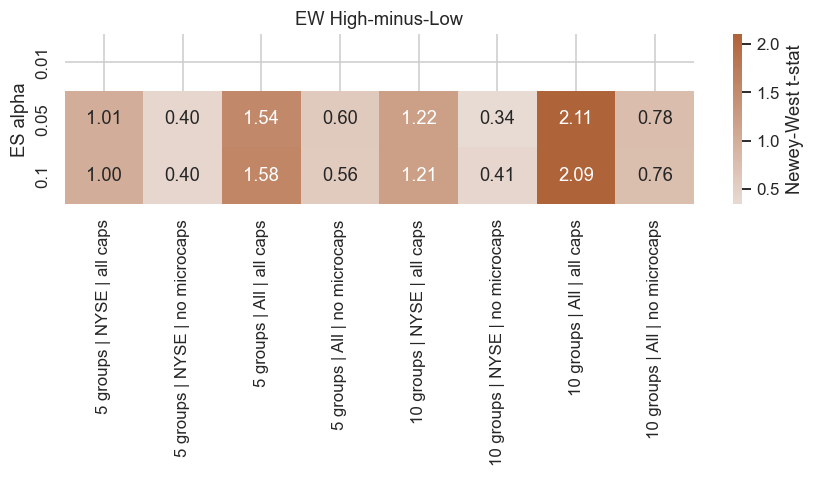

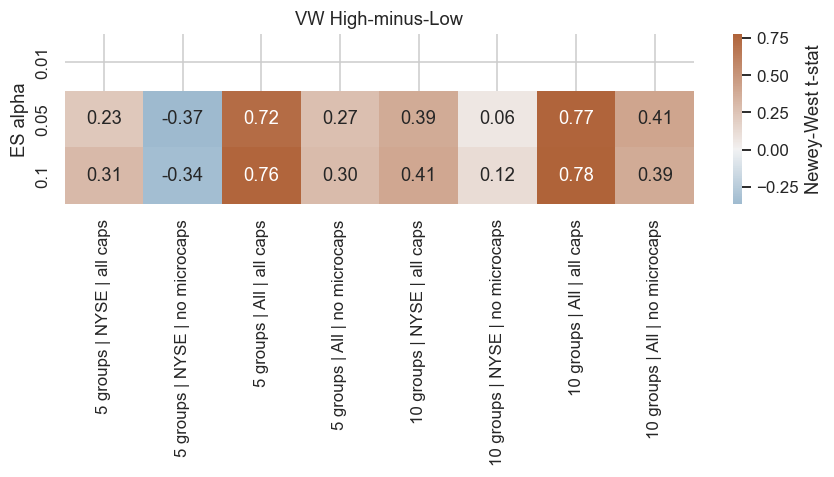

In [35]:
# ==========================================
# 9.2 图：稳健性设计中的 H-L t-statistics
# ==========================================
design_order = [
    f"{groups} groups | {bp} | {cap}"
    for groups in [5, 10] for bp in ["NYSE", "All"] for cap in ["all caps", "no microcaps"]
]


for weighting in ["EW", "VW"]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    heat = robustness_summary[robustness_summary["weighting"] == weighting].pivot(index="alpha", columns="design", values="nw_t")
    heat = heat.reindex(index=[0.01, 0.05, 0.10], columns=design_order)
    sns.heatmap(
        heat, annot=True, fmt=".2f", center=0,
        cmap=sns.diverging_palette(240, 30, as_cmap=True), cbar_kws={"label": "Newey-West t-stat"}, ax=ax,
    )
    ax.set(
        title=f"{weighting} High-minus-Low", 
        xlabel="", ylabel="ES alpha")
    fig.tight_layout()
    # fig.suptitle("Structured K3 portfolio-sort robustness", y=1.01)
    fig.savefig(figure_dir / f"fig10_robustness_heatmap_{weighting}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


## 10. Adverse weight 的经济验证

这里区分两类证据：当期 VIX 和信用利差只用于解释 `pi_adverse` 的经济含义；下一月市场收益、坏市场概率和股票横截面尾部损失才是样本外状态验证。坏市场定义为样本外市场超额收益最低的 10% 月份。

作者想证明：我算出来的这个 pi_adverse（不利状态概率/权重），不仅能用来选股，它本身还是一个极其敏锐的宏观风险预测指标。

crash_share：下个月市场, 跌幅超过 20% 的股票占比有多少？（全市场有多惨）。

cross_section_tail_return：下一月收益最低的 5% 股票的平均收益，亏损保留负数。

bad_market：下个月的大盘收益是不是处于历史最差的 10% 以内？（0 或 1）。

代码计算了你发明的 pi_adverse 指标与 VIX、信用利差等传统指标的相关系数 (state_macro_correlations)。


In [36]:
# ==========================================
# 10.1 构建下一月市场和横截面尾部结果
# ==========================================
# 10.1 构建下一月市场和横截面尾部结果
# ==========================================
# 这段代码的核心目的是对量化模型中预测的“市场尾部风险/不利状态（Adverse State）”进行事后检验与宏观经济学验证（Sanity Check）。
# 它将模型预测结果与真实世界的宏观经济指标（如恐慌指数、信用利差）、市场真实崩盘表现(下个月)进行了对齐，并计算了它们之间的关联度。
macro_data = pd.read_parquet(project_root / 'data/macro_data.parquet', columns=["mthcaldt", "VIXCLS", "CREDIT_SPREAD", "TERM_SPREAD"]) 
macro_data["mthcaldt"] = pd.to_datetime(macro_data["mthcaldt"])

realized_tail = pricing_base.groupby("mthcaldt", as_index=False).agg(
    crash_share=("target_ret_final", lambda x: np.mean(x < -0.20)),
    cross_section_tail_return=("target_ret_final", lambda x: x[x <= x.quantile(0.05)].mean()),
)
state_validation = state_monthly.copy()
state_validation["return_date"] = state_validation["mthcaldt"] + pd.offsets.MonthEnd(1)
state_validation = state_validation.merge(
    factor_data[["return_date", "mktrf_ff5"]], on="return_date", validate="one_to_one"
).merge(realized_tail, on="mthcaldt", validate="one_to_one"
).merge(macro_data, on="mthcaldt", how="left", validate="one_to_one"
        )
state_validation["bad_market"] = (state_validation["mktrf_ff5"] <= state_validation["mktrf_ff5"].quantile(0.10)).astype(int)

macro_cols = ["VIXCLS", "CREDIT_SPREAD", "TERM_SPREAD"]
macro_within = state_validation[["window", "pi_adverse_within_z", *macro_cols]].copy()
for column in macro_cols:
    macro_within[column] = macro_within[column] - macro_within.groupby("window")[column].transform("mean")
state_macro_correlations = macro_within[["pi_adverse_within_z", *macro_cols]].corr()
state_macro_correlations.to_parquet(result_dir / f"state_macro_correlations_{timestamp}.parquet", index=True)
display(state_macro_correlations.round(3))


,pi_adverse_within_z,VIXCLS,CREDIT_SPREAD,TERM_SPREAD
pi_adverse_within_z,1.000,0.024,-0.044,0.008
VIXCLS,0.024,1.000,0.731,0.026
CREDIT_SPREAD,-0.044,0.731,1.000,-0.095
TERM_SPREAD,0.008,0.026,-0.095,1.000


In [37]:
# ==========================================
# 10.2 pi_adverse 对下一月坏状态的预测回归
# ==========================================
state_outcomes = {
    "Next market excess return": "mktrf_ff5",
    "Bad-market probability": "bad_market",
    "Cross-sectional crash share": "crash_share",
    "Cross-sectional 5% tail return": "cross_section_tail_return",
}

rows = []
for outcome_name, outcome_col in state_outcomes.items():
    for state_spec, x_col, add_window_fe in [
        ("Global", "pi_adverse_global_z", False),
        ("Within-window + window FE", "pi_adverse_within_z", True),
    ]:
        data = state_validation[[outcome_col, x_col, "window"]].dropna().reset_index(drop=True)
        X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
        if add_window_fe:
            X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
        fit_state = sm.OLS(data[outcome_col], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
        rows.append({
            "outcome": outcome_name, "state_specification": state_spec,
            "coefficient_pi_adverse_z": fit_state.params[x_col], "nw_t": fit_state.tvalues[x_col],
            "p_value": fit_state.pvalues[x_col], "months": int(fit_state.nobs),
        })
state_validation_regressions = pd.DataFrame(rows)
state_validation_regressions.to_parquet(result_dir / f"state_validation_regressions_{timestamp}.parquet", index=False)
display(state_validation_regressions.round(5))


,outcome,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,Next market excess return,Global,-0.00166,-0.52675,0.59837,216
1,Next market excess return,Within-window + window FE,-0.00224,-0.83065,0.40617,216
2,Bad-market probability,Global,0.02257,0.97300,0.33055,216
3,Bad-market probability,Within-window + window FE,0.02274,0.98169,0.32625,216
4,Cross-sectional crash share,Global,0.00783,1.13070,0.25818,216
5,Cross-sectional crash share,Within-window + window FE,0.00838,1.39160,0.16404,216
6,Cross-sectional 5% tail return,Global,-0.00589,-0.75566,0.44985,216
7,Cross-sectional 5% tail return,Within-window + window FE,-0.00406,-0.80806,0.41906,216


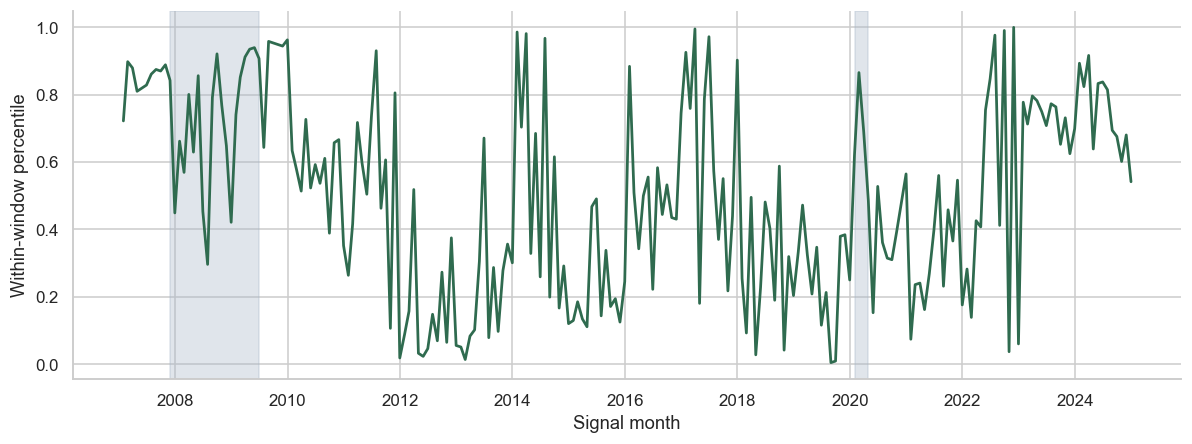

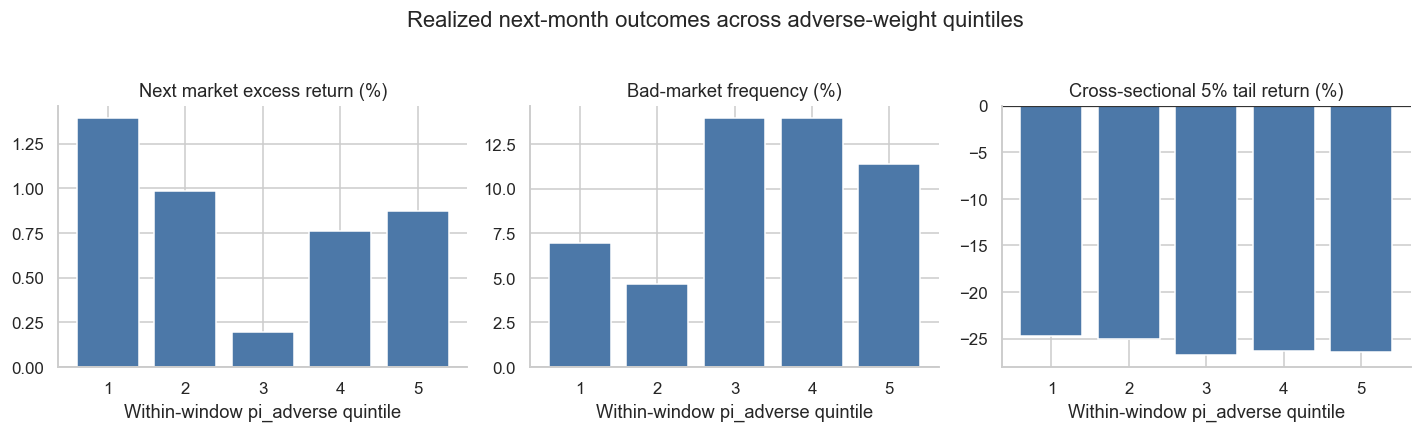

In [38]:
# ==========================================
# 10.3 图：窗口内 adverse-weight rank 和下一月结果
# ==========================================
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(state_validation["mthcaldt"], state_validation["pi_rank_global"], color="#2F6B4F", linewidth=1.8)
for start, end in [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#A7B7C7", alpha=0.35)
ax.set(
    # title="Within-window adverse component weight rank", 
    xlabel="Signal month", ylabel="Within-window percentile")
fig.tight_layout()
fig.savefig(figure_dir / f"fig11_adverse_weight_time_series.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


state_validation["pi_rank_global"] = pd.cut(state_validation["pi_rank_global"], np.linspace(0, 1, 6), labels=np.arange(1, 6), include_lowest=True)
state_bins = state_validation.groupby("pi_rank_global", observed=True).agg(
    market_return=("mktrf_ff5", "mean"), bad_market_rate=("bad_market", "mean"),
    tail_return=("cross_section_tail_return", "mean"), months=("mthcaldt", "size"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (column, title) in zip(axes, [
    ("market_return", "Next market excess return (%)"),
    ("bad_market_rate", "Bad-market frequency (%)"),
    ("tail_return", "Cross-sectional 5% tail return (%)"),
]):
    ax.bar(state_bins["pi_rank_global"].astype(int), 100 * state_bins[column], color="#4C78A8", edgecolor="white")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=title, xlabel="Within-window pi_adverse quintile", xticks=np.arange(1, 6))
fig.suptitle("Realized next-month outcomes across adverse-weight quintiles", y=1.03)
fig.tight_layout()
fig.savefig(figure_dir / f"fig12_adverse_weight_validation.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

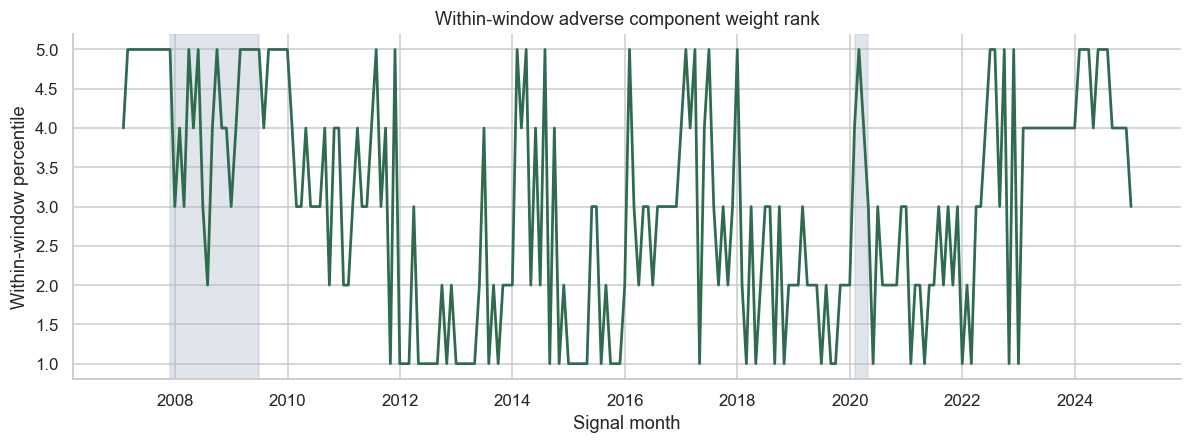

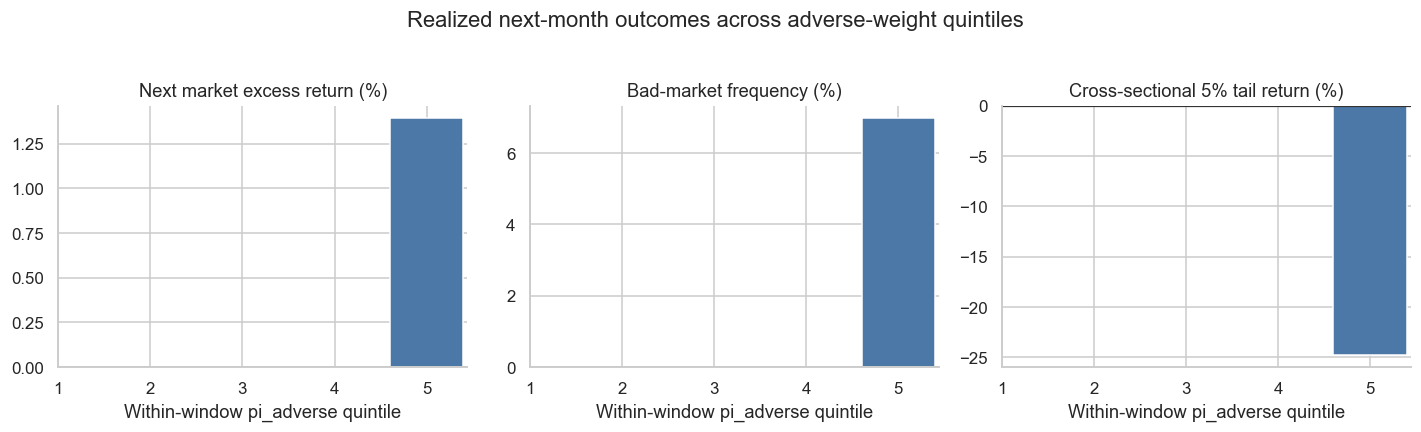

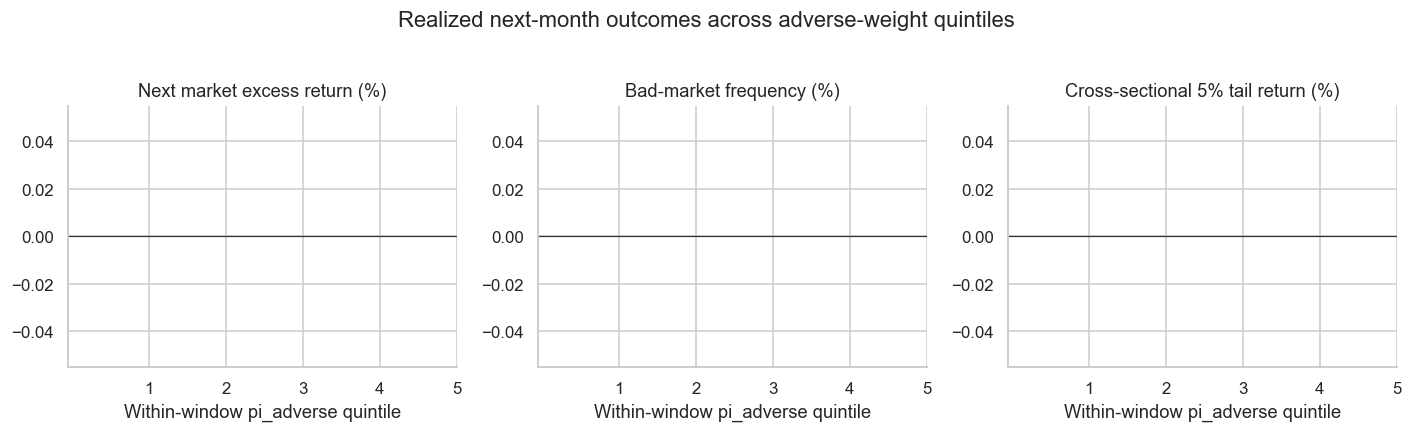

In [39]:
# ==========================================
# 10.3 图：窗口内 adverse-weight rank 和下一月结果
# ==========================================
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(state_validation["mthcaldt"], state_validation["pi_rank_global"], color="#2F6B4F", linewidth=1.8)
for start, end in [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#A7B7C7", alpha=0.35)
ax.set(title="Within-window adverse component weight rank", xlabel="Signal month", ylabel="Within-window percentile")
fig.tight_layout()
fig.savefig(figure_dir / f"fig11_adverse_weight_time_series.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

state_validation["pi_rank_global"] = pd.cut(state_validation["pi_rank_global"], np.linspace(0, 1, 6), labels=np.arange(1, 6), include_lowest=True)
state_bins = state_validation.groupby("pi_rank_global", observed=True).agg(
    market_return=("mktrf_ff5", "mean"), bad_market_rate=("bad_market", "mean"),
    tail_return=("cross_section_tail_return", "mean"), months=("mthcaldt", "size"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (column, title) in zip(axes, [
    ("market_return", "Next market excess return (%)"),
    ("bad_market_rate", "Bad-market frequency (%)"),
    ("tail_return", "Cross-sectional 5% tail return (%)"),
]):
    ax.bar(state_bins["pi_rank_global"].astype(int), 100 * state_bins[column], color="#4C78A8", edgecolor="white")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=title, xlabel="Within-window pi_adverse quintile", xticks=np.arange(1, 6))
fig.suptitle("Realized next-month outcomes across adverse-weight quintiles", y=1.03)
fig.tight_layout()
fig.savefig(figure_dir / f"fig12_adverse_weight_validation.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


state_validation["pi_rank_global"] = pd.cut(state_validation["pi_rank_global"], np.linspace(0, 1, 6), labels=np.arange(1, 6), include_lowest=True)
state_bins = state_validation.groupby("pi_rank_global", observed=True).agg(
    market_return=("mktrf_ff5", "mean"), bad_market_rate=("bad_market", "mean"),
    tail_return=("cross_section_tail_return", "mean"), months=("mthcaldt", "size"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (column, title) in zip(axes, [
    ("market_return", "Next market excess return (%)"),
    ("bad_market_rate", "Bad-market frequency (%)"),
    ("tail_return", "Cross-sectional 5% tail return (%)"),
]):
    ax.bar(state_bins["pi_rank_global"].astype(int), 100 * state_bins[column], color="#4C78A8", edgecolor="white")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(title=title, xlabel="Within-window pi_adverse quintile", xticks=np.arange(1, 6))
fig.suptitle("Realized next-month outcomes across adverse-weight quintiles", y=1.03)
fig.tight_layout()
fig.savefig(figure_dir / f"fig12_adverse_weight_validation.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


## 11. Severity 是否超越普通波动率

每个月先用 `sigma_bench`、规模、账面市值比和动量解释 adverse severity，再使用剩余部分进行组合排序和 Fama–MacBeth。该检验直接回答 severity 是否只是一个复杂的波动率信号。就是看残差是否显著


In [40]:
# ==========================================
# 11.1 构造横截面 residual severity
# ==========================================
def residualize_monthly(panel, dependent, controls, output_col):
    required = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse", dependent, *controls]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    work = standardize_monthly(work, [dependent, *controls])
    work[output_col] = np.nan
    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        X = sm.add_constant(month[[f"z_{c}" for c in controls]].to_numpy(dtype=float))
        y = month[f"z_{dependent}"].to_numpy(dtype=float)
        work.loc[positions, output_col] = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    return work


residual_severity_panel = residualize_monthly(
    pricing_base, "severity_adverse_5", control_cols, "severity_residual"
)
residual_severity_slopes = run_fama_macbeth(
    residual_severity_panel, "severity_residual", "residual_adverse_severity",
    "Residual adverse severity", "Residual adverse severity",
)
residual_severity_fmb = summarize_fama_macbeth(residual_severity_slopes)

residual_severity_portfolios = sort_portfolios(residual_severity_panel, "severity_residual", PRIMARY_GROUPS, me_breakpoints, exclude_microcaps, breakpoint_universe=breakpoint_universe)
residual_metadata = {
    "model_id": "residual_adverse_severity", "model_label": "Residual adverse severity",
    "signal_name": "Residual adverse severity", "n_groups": PRIMARY_GROUPS,
    "exclude_microcaps": False, "breakpoint_universe": "NYSE",
}
residual_severity_hml = build_hml(residual_severity_portfolios, residual_metadata)
residual_severity_hml_summary = summarize_hml(residual_severity_hml)
# display(residual_severity_fmb[residual_severity_fmb["specification"] == "Controls"][[
#     "signal_name", "annualized_slope_pct", "nw_t", "p_value"
# ]].round(4))
# display(residual_severity_hml_summary[["weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))
residual_severity_fmb.to_parquet(result_dir / f"residual_severity_fmb_{timestamp}.parquet", index=False)
residual_severity_hml_summary.to_parquet(result_dir / f"residual_severity_hml_summary_{timestamp}.parquet", index=False)
display(residual_severity_fmb.round(4))
display(residual_severity_hml_summary.round(4))


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls,0.0004,0.0008,0.5828,0.5600,-0.0011,0.0019,216,0.5354,-1.2650,2.3358
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls+IndustryFE,0.0005,0.0009,0.5358,0.5921,-0.0013,0.0023,216,0.5867,-1.5597,2.7331
2,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Univariate,0.0005,0.0008,0.6585,0.5102,-0.0010,0.0021,216,0.6240,-1.2334,2.4814


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,EW,10,False,NYSE,0.0013,0.0025,0.5381,0.5905,-0.0035,0.0062,216,1.6027,-4.2352,7.4405
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,VW,10,False,NYSE,-0.0031,0.0033,-0.9183,0.3584,-0.0096,0.0035,216,-3.6865,-11.5544,4.1814


## 12. State-dependent pricing horse race

使用同一个 Structured `pi_adverse` 分别解释五个模型总 ES、adverse contribution、raw severity 和 residual severity 的月度价格斜率。若简单模型也得到相同结果，经济事实仍成立，但 Structured decomposition 不是必要条件。


逻辑： 正如中文注释所说：“若简单模型也得到相同结果……Structured decomposition 就不是必要条件。”所以这里引入了一个简单的基准模型叫 linear_quantile。

做法：

代码首先计算了“复杂模型斜率”与“简单模型斜率”的差值（difference = wide[candidate] - wide["linear_quantile"]）。

然后用市场状态 pi_adverse 去回归这个差值。

结论如何看： 如果回归结果显著（p_value 很小，nw_t 绝对值很大），说明复杂模型对恶劣市场状态的敏感度显著区别于（且通常是优于）简单的线性模型。这就证明了研究者费尽心思搞出来的“结构化分解”是不可替代的，是有学术价值的。

In [41]:
# ==========================================
# 12.1 月度 signal price 对 adverse weight 的回归
# ==========================================
def state_price_regression(slopes, state):
    #回归公式: signal_slope = β0 + β1 * adverse_weight + ε
    rows = []
    group_cols = ["model_id", "model_label", "signal_name"]
    for keys, group in slopes[slopes["specification"] == "Controls"].groupby(group_cols):
        data = group.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_spec, x_col, add_window_fe in [
            ("Global", "pi_adverse_global_z", False),
            ("Within-window + window FE", "pi_adverse_within_z", True),
        ]:
            X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
            if add_window_fe:
                X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit_price = sm.OLS(data["signal_slope"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            ci = fit_price.conf_int().loc[x_col]
            rows.append({
                **dict(zip(group_cols, keys)), "state_specification": state_spec,
                "coefficient": fit_price.params[x_col], "nw_t": fit_price.tvalues[x_col], "p_value": fit_price.pvalues[x_col],
                "ci_95_low": ci.iloc[0], "ci_95_high": ci.iloc[1], "months": int(fit_price.nobs),
            })
    return pd.DataFrame(rows)


def compare_state_price_to_linear(slopes, state):
    # 回归公式: slope_difference = β0 + β1 * adverse_weight + ε
    controls = slopes[slopes["specification"] == "Controls"]
    wide = controls.pivot(index="mthcaldt", columns="model_label", values="signal_slope")
    candidates = ["Structured Normal K3", "Adverse contribution", "Adverse severity", "Residual adverse severity"]
    # labels = wide.columns.to_list()
    labels = controls.drop_duplicates("model_label").set_index("model_label")["model_id"].to_dict()
    rows = []
    for candidate in candidates:
        difference = (wide[candidate] - wide["Linear Quantile"]).rename("slope_difference").reset_index()
        data = difference.merge(state, on="mthcaldt", validate="one_to_one").dropna().reset_index(drop=True)
        for state_spec, x_col, add_window_fe in [
            ("Global", "pi_adverse_global_z", False),
            ("Within-window + window FE", "pi_adverse_within_z", True),
        ]:
            X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
            if add_window_fe:
                X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit_diff = sm.OLS(data["slope_difference"], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            rows.append({
                "model_id": labels[candidate], "model_label": candidate, "benchmark": "Linear Quantile",
                "state_specification": state_spec, "difference_coefficient": fit_diff.params[x_col],
                "nw_t": fit_diff.tvalues[x_col], "p_value": fit_diff.pvalues[x_col], "months": int(fit_diff.nobs),
            })
    return pd.DataFrame(rows)


horse_race_slopes = pd.concat([fmb_monthly_slopes, residual_severity_slopes], ignore_index=True)
state_price_horse_race = state_price_regression(horse_race_slopes, state_monthly)
state_price_vs_linear = compare_state_price_to_linear(horse_race_slopes, state_monthly)
state_price_horse_race.to_parquet(result_dir / f"state_price_horse_race_{timestamp}.parquet", index=False)
state_price_vs_linear.to_parquet(result_dir / f"state_price_vs_linear_{timestamp}.parquet", index=False)
display(state_price_horse_race[["model_label", "state_specification", "coefficient", "nw_t", "p_value"]].round(5))
display(state_price_vs_linear.round(5))


,model_label,state_specification,coefficient,nw_t,p_value
0,Fused Normal K1,Global,0.00043,0.31138,0.75551
1,Fused Normal K1,Within-window + window FE,0.00117,0.83986,0.40099
2,Fused Normal K3,Global,0.00025,0.19245,0.84739
3,Fused Normal K3,Within-window + window FE,0.00111,0.92676,0.35405
4,Linear Quantile,Global,0.00051,0.48271,0.62930
5,Linear Quantile,Within-window + window FE,0.00168,1.42510,0.15413
6,Residual adverse severity,Global,0.00004,0.06446,0.94861
7,Residual adverse severity,Within-window + window FE,0.00048,0.81056,0.41762
8,Rolling Normal,Global,-0.00172,-2.29393,0.02179
9,Rolling Normal,Within-window + window FE,-0.00054,-0.72226,0.47014


,model_id,model_label,benchmark,state_specification,difference_coefficient,nw_t,p_value,months
0,structured_normal_k3,Structured Normal K3,Linear Quantile,Global,-0.00059,-0.84309,0.39918,216
1,structured_normal_k3,Structured Normal K3,Linear Quantile,Within-window + window FE,-0.00076,-1.24382,0.21357,216
2,structured_normal_k3,Adverse contribution,Linear Quantile,Global,0.00104,0.92493,0.35500,216
3,structured_normal_k3,Adverse contribution,Linear Quantile,Within-window + window FE,0.00130,1.28230,0.19974,216
4,structured_normal_k3,Adverse severity,Linear Quantile,Global,-0.00040,-0.56255,0.57374,216
5,structured_normal_k3,Adverse severity,Linear Quantile,Within-window + window FE,-0.00060,-1.01742,0.30895,216
6,residual_adverse_severity,Residual adverse severity,Linear Quantile,Global,-0.00046,-0.72542,0.46820,216
7,residual_adverse_severity,Residual adverse severity,Linear Quantile,Within-window + window FE,-0.00120,-1.57759,0.11466,216


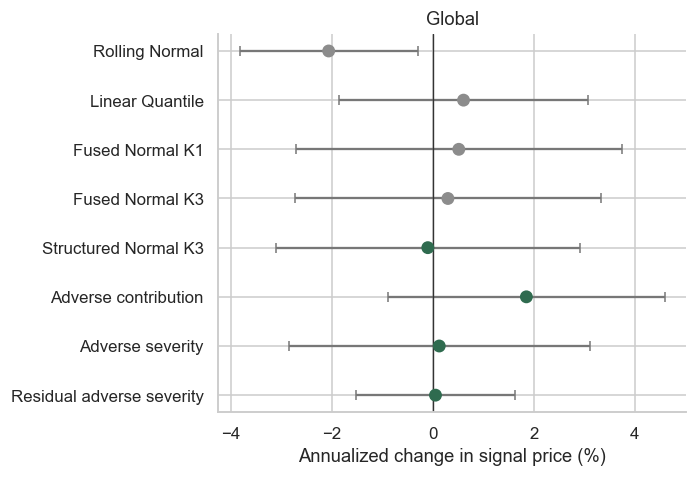

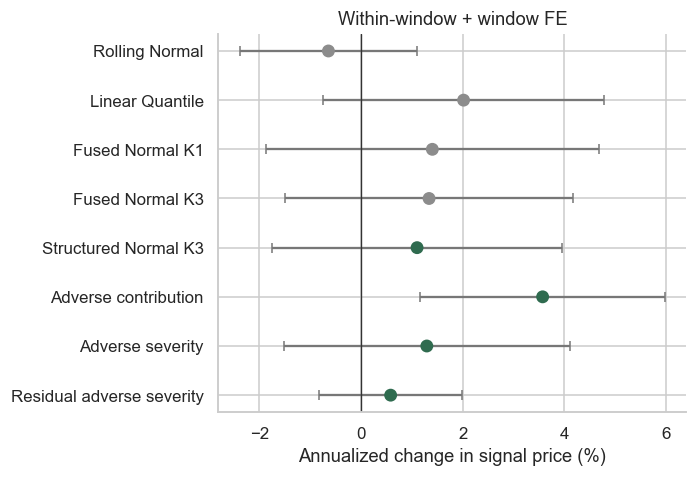

In [42]:
# ==========================================
# 12.2 图：不同 tail signals 的状态依赖价格
# ==========================================
horse_order = [*model_labels.values(), "Adverse contribution", "Adverse severity", "Residual adverse severity"]
# fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)
for state_spec in ["Global", "Within-window + window FE"]:
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    plot_data = state_price_horse_race[state_price_horse_race["state_specification"] == state_spec].set_index("model_label").reindex(horse_order).dropna().reset_index()
    plot_data["estimate"] = 1200 * plot_data["coefficient"]
    plot_data["low"], plot_data["high"] = 1200 * plot_data["ci_95_low"], 1200 * plot_data["ci_95_high"]
    y = np.arange(len(plot_data))
    colors = ["#2F6B4F" if ("Adverse" in label or "Residual" in label or label == "Structured Normal K3") else "#8C8C8C" for label in plot_data["model_label"]]
    ax.errorbar(plot_data["estimate"], y, xerr=[plot_data["estimate"] - plot_data["low"], plot_data["high"] - plot_data["estimate"]], fmt="none", ecolor="#777777", capsize=3)
    ax.scatter(plot_data["estimate"], y, c=colors, s=55, zorder=3)
    ax.axvline(0, color="#333333", linewidth=0.9)
    ax.set(
        title=state_spec, 
        xlabel="Annualized change in signal price (%)", yticks=y, yticklabels=plot_data["model_label"])
    ax.invert_yaxis()
# fig.suptitle("State-dependent pricing across tail-risk signals", y=1.02)
    fig.tight_layout()  
    fig.savefig(figure_dir / f"fig13_state_price_horse_race_{state_spec.replace(' ', '_').replace('+', 'plus').replace('-', 'minus')}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


## 13. 极端 ES 组合的公司特征

下面检查极端 ES 组合的公司特征；收益率口径下第 1 组为最低 ES（最严重尾部亏损），第 10 组为最高 ES。比较其规模、波动率、账面市值比和动量，不预设哪组收益骤降。所有特征先在月内 winsorize 并标准化，再对月份等权平均。


In [43]:
# ==========================================
# 13.1 Structured ES deciles 的特征轮廓
# ==========================================
def assign_nyse_groups(panel, signal_col, n_groups=10):
    work = panel.copy().reset_index(drop=True)
    groups = np.empty(len(work), dtype=np.int8)
    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        breaks = np.quantile(month.loc[:, signal_col], np.arange(1, n_groups) / n_groups)
        groups[positions] = np.searchsorted(breaks, month[signal_col].to_numpy(), side="right") + 1
    work["portfolio"] = groups
    return work


diagnostic_panel = standardize_monthly(assign_nyse_groups(pricing_base, "es_5", PRIMARY_GROUPS), control_cols)

# diagnostic_panel = assign_signal_groups(
#     panel=pricing_base,
#     signal_col="es_5",
#     n_groups=PRIMARY_GROUPS,
#     breakpoint_universe="NYSE",
#     me_breakpoints_df=me_breakpoints,
#     exclude_microcaps=False,
# )

# diagnostic_panel = standardize_monthly(
#     diagnostic_panel,
#     control_cols,
# )


# diagnostic_cols = {"mthcap_log": "Size", "sigma_bench": "Volatility", "bm": "Book-to-market", "MOM12m": "Momentum"}
diagnostic_cols = {"mthcap_log": "Size","bm": "Book-to-market",}
decile_characteristics = diagnostic_panel.groupby(["mthcaldt", "portfolio"], as_index=False).agg(
    **{label: (f"z_{column}", "mean") for column, label in diagnostic_cols.items()}
).groupby("portfolio", as_index=False).mean(numeric_only=True)

display(decile_characteristics.round(3))


,portfolio,Size,Book-to-market
0,1,-0.720,-0.252
1,2,-0.571,0.016
2,3,-0.455,0.133
3,4,-0.330,0.146
4,5,-0.188,0.134
5,6,-0.044,0.099
6,7,0.121,0.052
7,8,0.357,-0.055
8,9,0.690,-0.178
9,10,1.140,-0.102


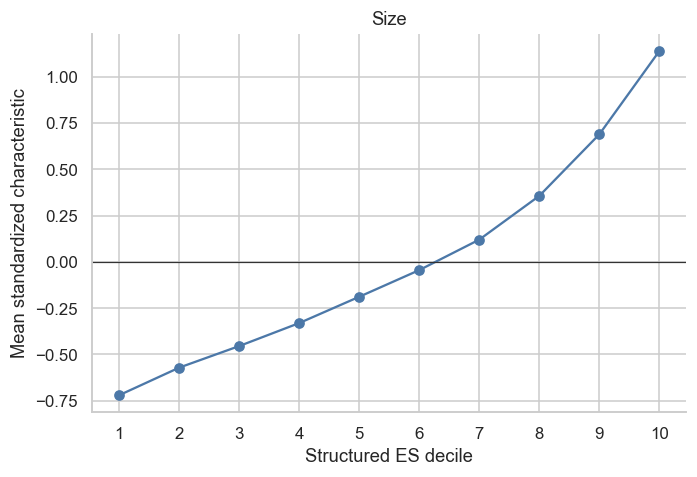

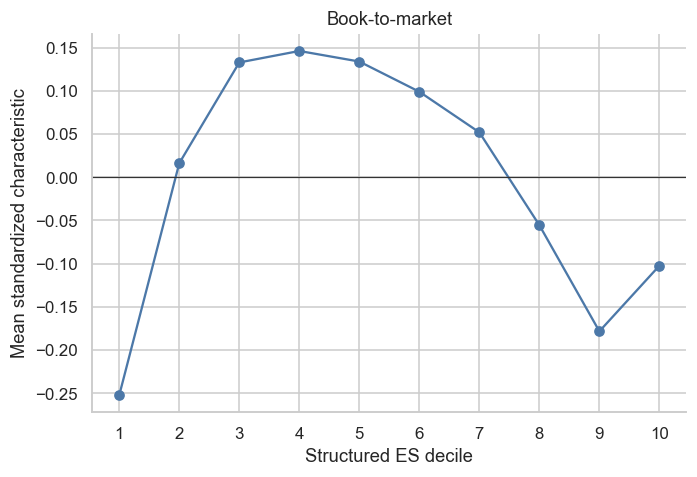

In [44]:

for label in diagnostic_cols.values():
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.plot(decile_characteristics["portfolio"], decile_characteristics[label], marker="o", color="#4C78A8")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(
        title=label, 
        xlabel="Structured ES decile", ylabel="Mean standardized characteristic", xticks=np.arange(1, 11))
    ax.set_aspect("auto")
    # fig.suptitle("Firm characteristics across Structured 5% return-ES deciles", y=1.01)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig14_es_decile_characteristics_{label.replace(' ', '_').lower()}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)

# ---------------------------------------------------------
# 下面的暂时不要
# ---------------------------------------------------------

## 14. 外部可观测坏状态(这一部分我觉得没意义, 不要了)

模型自己的 $\pi_{adverse}$ 没有可靠地预测下一期市场坏状态，因此本节不再用它定义宏观状态。主检验改用预测时点 $t$ 已知的三个外部指标：VIX、信用利差和过去 12 个月市场峰值回撤。

先分别标准化三个指标，再等权平均并重新标准化：

$$
Stress_t=Z\left[\frac{Z(VIX_t)+Z(CreditSpread_t)+Z(Drawdown_t)}{3}\right].
$$

`Stress` 越高表示当期金融环境越差。全样本标准化只改变回归系数的单位，不用于预测未来信息；三个单项指标作为分项结果，等权综合指标是预先确定的主检验。

## 15. 保存结果
